# ***Car Price Prediction - Regression***
***Dec 2025***

# 🔶Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, boxcox, yeojohnson
import datetime as dt

import missingno as msno

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  FunctionTransformer, PowerTransformer, QuantileTransformer,MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

import joblib

# 🔶Data Overview

**Used-Car Price Prediction Using Regression Models**

This project develops and evaluates supervised regression models to predict used car selling prices based on vehicle characteristics and market attributes.

**Car Price Dataset**

The dataset contains 301 records and includes both numerical and categorical attributes commonly associated with vehicle valuation, such as usage indicators, fuel type, ownership history, and market price.


| **Column Name**              | **Description**|
| ---------------------------- | ---------------------------------- |
| **Kms_Driven**               | Total kilometers the car has been driven (indicator of usage).     |
| **Fuel_Type**                | Type of fuel used: Petrol, Diesel, or CNG.                           |
| **Seller_Type**              | Seller category: Individual or Dealer.                        |
| **Transmission**             | Transmission type: Manual or Automatic.                     |
| **Owner**                    | Number of previous owners.                        |
| **Year**                     | Manufacturing year of the car.                           |
| **Present_Price**            | Current market/initial purchase price of the car.                           |
| **Selling_Price** *(Target)* | Final selling price of the car.                           |


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/cardata.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
print(f'Shape of the Dataset:{df.shape}')
pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isnull().sum().values,
    "unique_values": df.nunique().values
    })

Shape of the Dataset:(301, 9)


,column,dtype,missing_values,unique_values
0,Car_Name,object,0,98
1,Year,int64,0,16
2,Selling_Price,float64,0,156
3,Present_Price,float64,0,147
4,Kms_Driven,int64,0,206
5,Fuel_Type,object,0,3
6,Seller_Type,object,0,2
7,Transmission,object,0,2
8,Owner,int64,0,3


**Initial Dataset Inspection**

The dataset contains 301 observations across nine features, including four categorical variables and five numerical fields. All fields are complete, and no missing values are reported.

Car_Name  will be dropped later as it contains no useful information for this project.

#  🔶Data Type Casting

In [ ]:
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    print(col, df[col].unique())


Fuel_Type ['Petrol' 'Diesel' 'CNG']
Seller_Type ['Dealer' 'Individual']
Transmission ['Manual' 'Automatic']
Owner [0 1 3]


In [ ]:
# Casting object to categorical data & integer to float data
df = df.astype({
    'Car_Name': 'category',
    'Year': 'float64',
    'Kms_Driven': 'float64',
    'Fuel_Type': 'category',
    'Seller_Type': 'category',
    'Transmission': 'category',
    'Owner': 'category'
})

df.dtypes

,0
Car_Name,category
Year,float64
Selling_Price,float64
Present_Price,float64
Kms_Driven,float64
Fuel_Type,category
Seller_Type,category
Transmission,category
Owner,category


# 🔶Feature Engineering

Here, an Age variable is generated, which more intuitively represents vehicle longevity compared to the raw manufacturing year.

In [ ]:
# Making 'Age' column out of 'Year' column
current_year = dt.datetime.now().year
df['Age'] = current_year - df['Year']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014.0,3.35,5.59,27000.0,Petrol,Dealer,Manual,0,11.0
1,sx4,2013.0,4.75,9.54,43000.0,Diesel,Dealer,Manual,0,12.0
2,ciaz,2017.0,7.25,9.85,6900.0,Petrol,Dealer,Manual,0,8.0
3,wagon r,2011.0,2.85,4.15,5200.0,Petrol,Dealer,Manual,0,14.0
4,swift,2014.0,4.60,6.87,42450.0,Diesel,Dealer,Manual,0,11.0


In [ ]:
# Dropping unnecessary columns
cols_to_drop =['Year', 'Car_Name']
df.drop(cols_to_drop, axis=1, inplace=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000.0,Petrol,Dealer,Manual,0,11.0
1,4.75,9.54,43000.0,Diesel,Dealer,Manual,0,12.0
2,7.25,9.85,6900.0,Petrol,Dealer,Manual,0,8.0
3,2.85,4.15,5200.0,Petrol,Dealer,Manual,0,14.0
4,4.60,6.87,42450.0,Diesel,Dealer,Manual,0,11.0


In [ ]:
# Reorder the columns
new_order = [
    'Age',
    'Present_Price',
    'Kms_Driven',
    'Owner',
    'Seller_Type',
    'Transmission',
    'Fuel_Type',
    'Selling_Price'
]

df = df[new_order]
df.head()

,Age,Present_Price,Kms_Driven,Owner,Seller_Type,Transmission,Fuel_Type,Selling_Price
0,11.0,5.59,27000.0,0,Dealer,Manual,Petrol,3.35
1,12.0,9.54,43000.0,0,Dealer,Manual,Diesel,4.75
2,8.0,9.85,6900.0,0,Dealer,Manual,Petrol,7.25
3,14.0,4.15,5200.0,0,Dealer,Manual,Petrol,2.85
4,11.0,6.87,42450.0,0,Dealer,Manual,Diesel,4.60


# 🔶Train-Test Split

In [ ]:
train_df , test_df = train_test_split(df, test_size=0.20, random_state=42)
train_df.shape, test_df.shape

((240, 8), (61, 8))

The dataset contains 301 observations, which are now split into:
* 240 samples (80%) for training the regression models.
* 61 samples (20%) for testing model performance.

The test set will be set aside until the final evaluation of the model

# 🔶Missing Values

<Axes: >

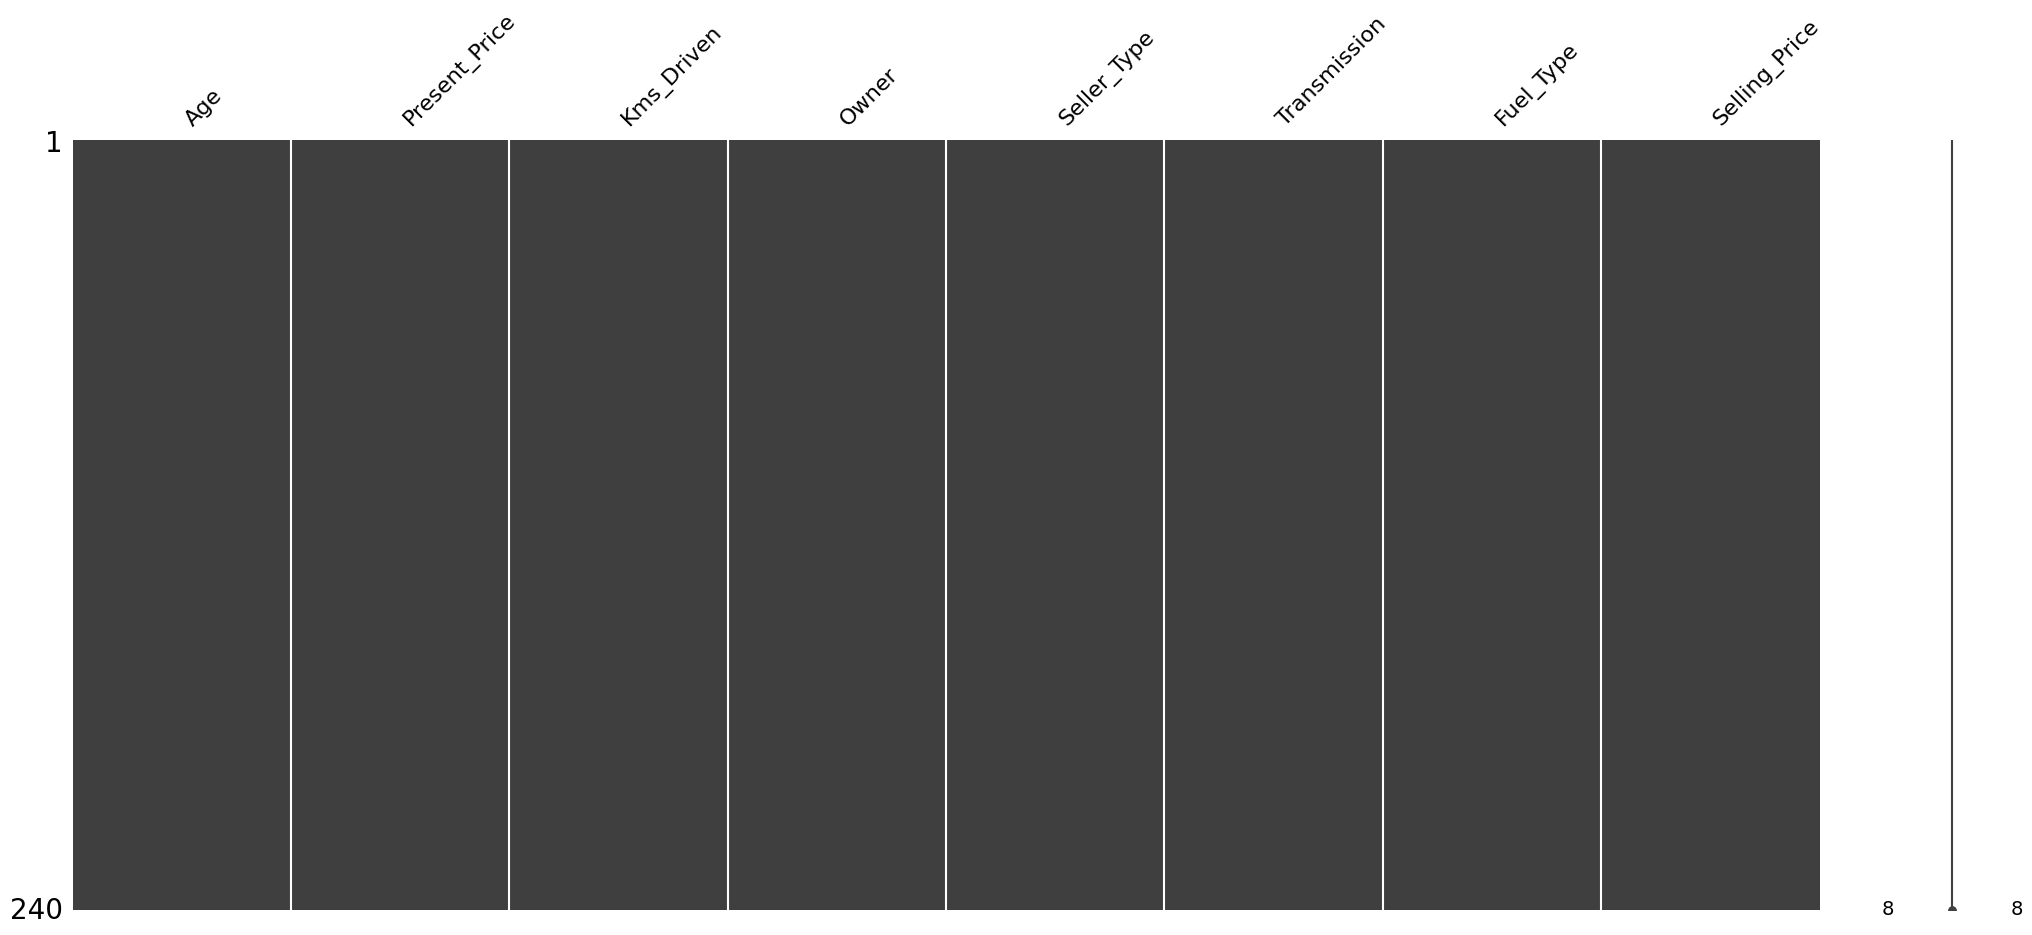

In [ ]:
msno.matrix(train_df)

In [ ]:
train_df.isna().sum()

,0
Age,0
Present_Price,0
Kms_Driven,0
Owner,0
Seller_Type,0
Transmission,0
Fuel_Type,0
Selling_Price,0


# 🔶Encoding Categoricl Features

In [ ]:
# Make a copy of the train_df
preprocessed_train_df = train_df.copy()

In [ ]:
print(preprocessed_train_df.Owner.unique())
print(preprocessed_train_df.Fuel_Type.unique())
print(preprocessed_train_df.Seller_Type.unique())
print(preprocessed_train_df.Transmission.unique())

[1, 0, 3]
Categories (3, int64): [0, 1, 3]
['Petrol', 'Diesel', 'CNG']
Categories (3, object): ['CNG', 'Diesel', 'Petrol']
['Individual', 'Dealer']
Categories (2, object): ['Dealer', 'Individual']
['Manual', 'Automatic']
Categories (2, object): ['Automatic', 'Manual']


In [ ]:
# One-hot-encoding of Owner & Fuel_Type
preprocessed_train_df = pd.get_dummies(preprocessed_train_df, columns=['Owner', 'Fuel_Type'], dtype=np.float64)
preprocessed_train_df.head()

,Age,Present_Price,Kms_Driven,Seller_Type,Transmission,Selling_Price,Owner_0,Owner_1,Owner_3,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
184,17.0,0.750,26000.0,Individual,Manual,0.25,0.0,1.0,0.0,0.0,0.0,1.0
132,8.0,0.950,3500.0,Individual,Manual,0.75,1.0,0.0,0.0,0.0,0.0,1.0
194,17.0,0.787,50000.0,Individual,Manual,0.20,1.0,0.0,0.0,0.0,0.0,1.0
75,10.0,6.800,36000.0,Dealer,Manual,3.95,1.0,0.0,0.0,0.0,0.0,1.0
111,9.0,1.500,8700.0,Individual,Manual,1.15,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Label-encoding binary variables
preprocessed_train_df = pd.get_dummies(preprocessed_train_df, columns=['Seller_Type', 'Transmission'], dtype=np.float64, drop_first=True)
preprocessed_train_df.head()

,Age,Present_Price,Kms_Driven,Selling_Price,Owner_0,Owner_1,Owner_3,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
184,17.0,0.750,26000.0,0.25,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
132,8.0,0.950,3500.0,0.75,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
194,17.0,0.787,50000.0,0.20,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
75,10.0,6.800,36000.0,3.95,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
111,9.0,1.500,8700.0,1.15,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


In [ ]:
# Reorder the columns
cols = [c for c in preprocessed_train_df.columns if c != 'Selling_Price'] + ['Selling_Price']
preprocessed_train_df = preprocessed_train_df[cols]

preprocessed_train_df.head()

,Age,Present_Price,Kms_Driven,Owner_0,Owner_1,Owner_3,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Selling_Price
184,17.0,0.750,26000.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.25
132,8.0,0.950,3500.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.75
194,17.0,0.787,50000.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.20
75,10.0,6.800,36000.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.95
111,9.0,1.500,8700.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.15


# 🔶Explanatory Data Analysis(EDA)

## ⮞Univariate Analysis

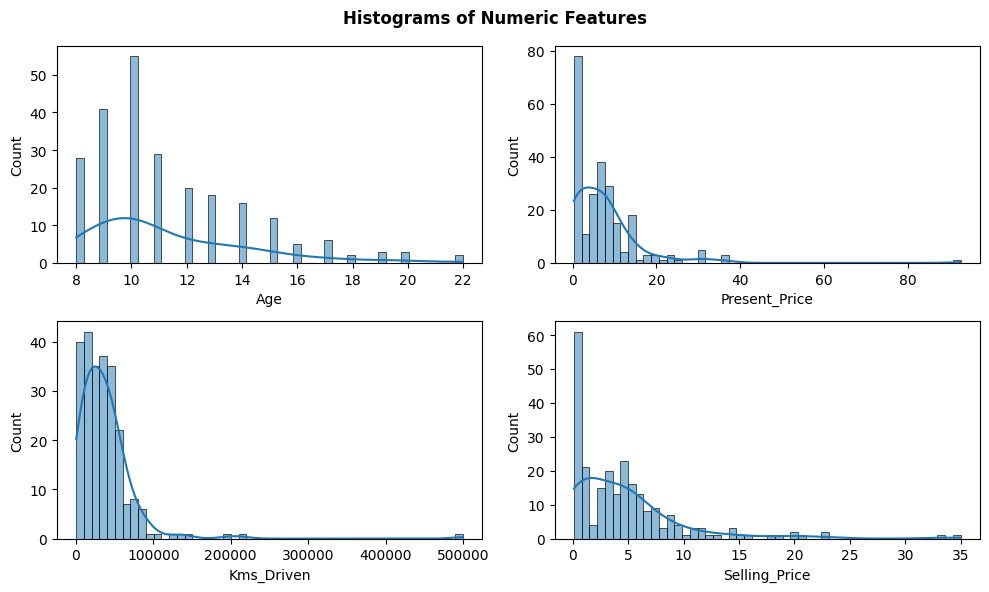

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven', 'Selling_Price']
fig, ax = plt.subplots(2,2, figsize=(10,6))
plt.suptitle('Histograms of Numeric Features', weight='bold')
flatten_ax = ax. flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.histplot(preprocessed_train_df[col], bins=50, kde=True, ax=ax)

plt.tight_layout()
plt.show()

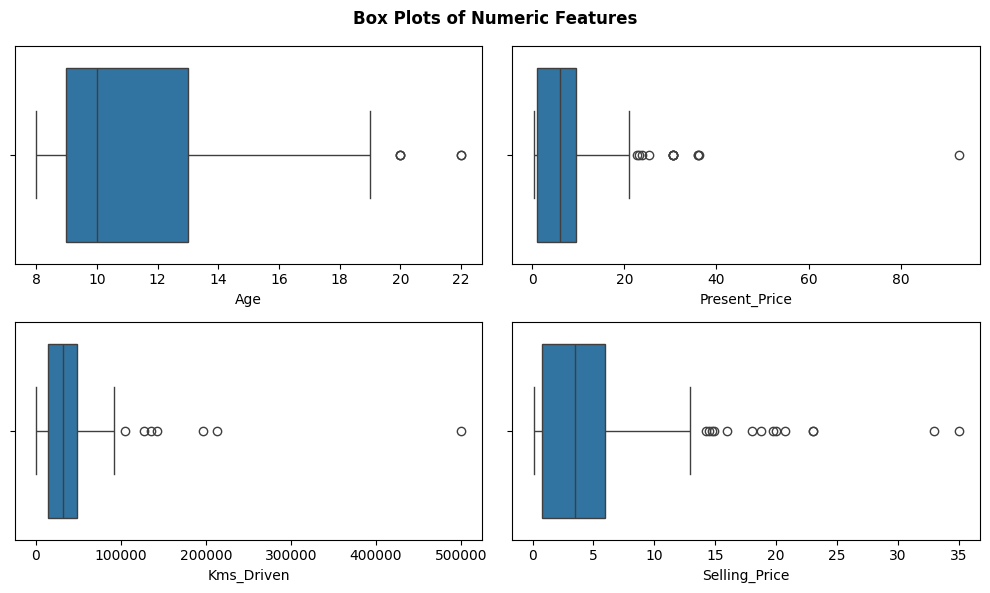

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(10,6))
plt.suptitle('Box Plots of Numeric Features', weight='bold')
flatten_ax = ax.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.boxplot(preprocessed_train_df[col], ax=ax, orient='h')

plt.tight_layout()
plt.show()

* **Histograms:**

  From the histograms, we can observe that all four numerical features exhibit varying degrees of right skewness. There are also some extremely large values, indicating the presence of outliers in the data.

* **Boxplots:**

  The boxplots confirm the presence of these outliers and allow us to visualize the spread and central tendency of each feature more clearly.

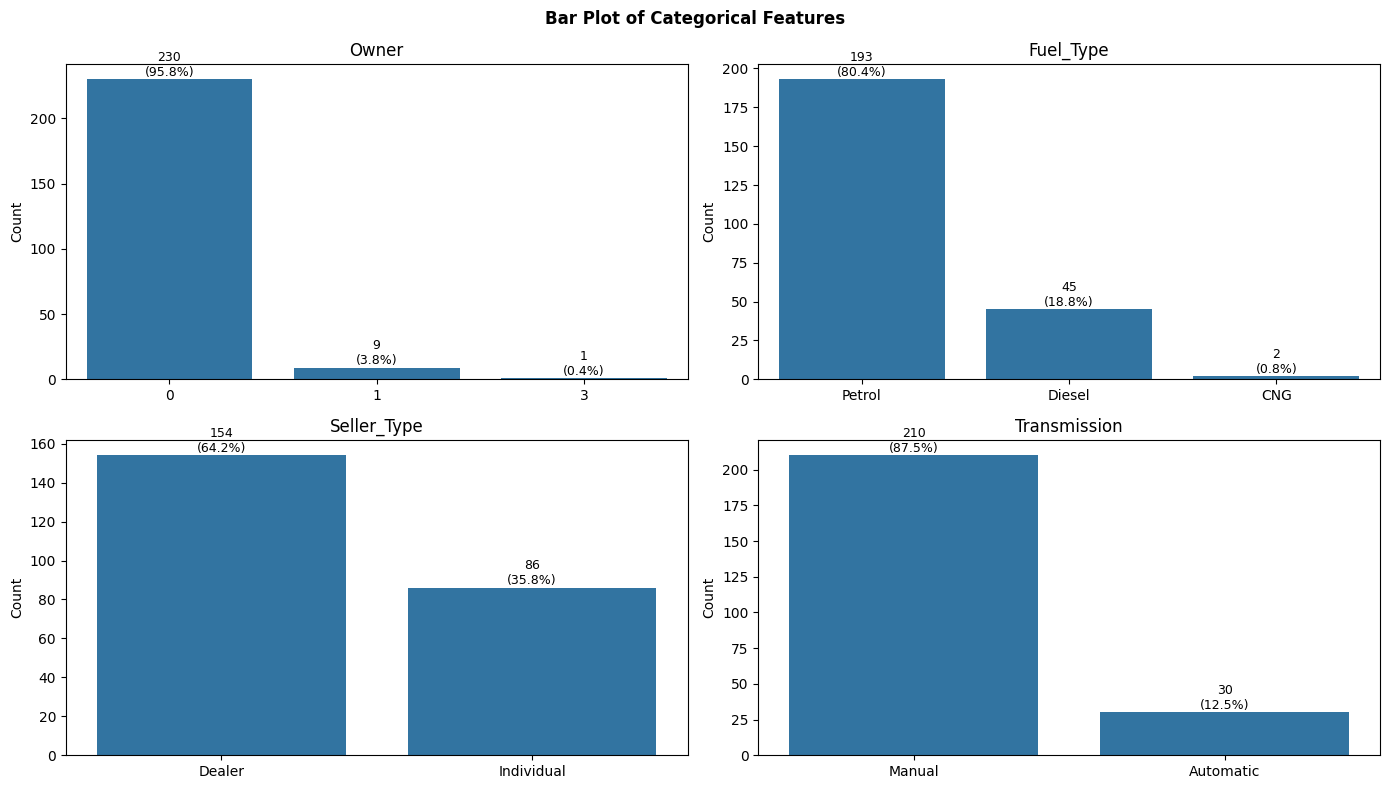

In [ ]:
categorical_cols=['Owner','Fuel_Type', 'Seller_Type', 'Transmission']

fig, ax = plt.subplots(2,2, figsize=(14,8))
plt.suptitle('Bar Plot of Categorical Features', weight='bold')
flatten_ax = ax.flatten()

for i , col in enumerate(categorical_cols):
  ax= flatten_ax[i]

  # order by frequency (descending)
  vc = train_df[col].value_counts()
  order = vc.index.tolist()
  # countplot (bars = counts)
  sns.countplot(data=train_df, x=col, order=order, ax=ax)

  # annotate counts and percentages above bars
  for p in ax.patches:
      count = int(p.get_height())
      pct = count / len(train_df) * 100
      x = p.get_x() + p.get_width() / 2
      y = p.get_height()
      ax.text(x, y + len(train_df)*0.001, f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

  ax.set_title(col)
  ax.set_xlabel('')
  ax.set_ylabel('Count')
  ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

* Owner: Approximately 95% of cars have zero previous owners, while less than 1% have three previous owners. This shows that the data is highly unbalanced in terms of ownership history.
* Fuel_Type: About 80% of vehicles use petrol, 18% use diesel, and less than 1% use CNG, indicating a strong class imbalance.
* Seller_Type: Around 65% of the cars are sold by dealers, highlighting an uneven distribution of seller types.
* Transmission: Most cars (87%) have manual transmission, showing a significant imbalance in transmission types.

Overall, the categorical features are highly skewed toward certain categories, which is important to consider during modeling, as it may influence predictive performance.

## ⮞Bivariate Analysis

<Axes: >

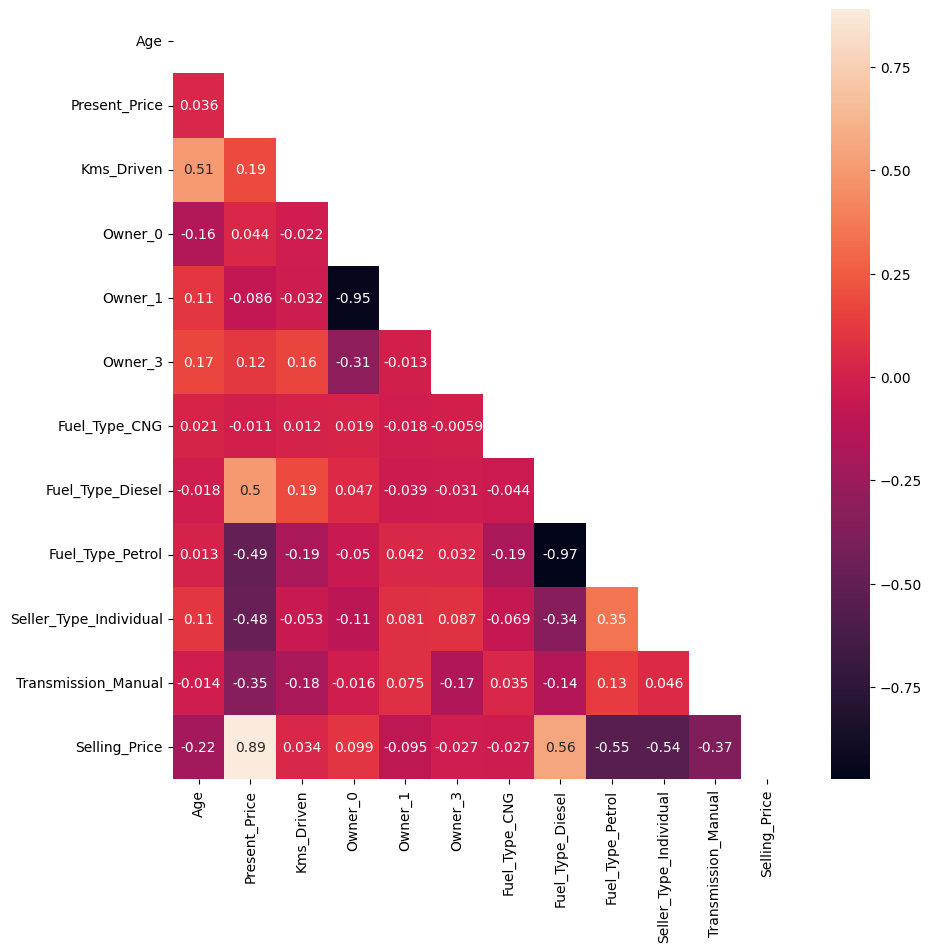

In [ ]:
plt.figure(figsize=(10,10))
corr = preprocessed_train_df.corr()
sns.heatmap(corr, annot=True, mask=np.triu(corr))

In [ ]:
corr[['Selling_Price']].abs().sort_values(by='Selling_Price', ascending=False)

,Selling_Price
Selling_Price,1.000000
Present_Price,0.889505
Fuel_Type_Diesel,0.561523
Fuel_Type_Petrol,0.545987
Seller_Type_Individual,0.542972
Transmission_Manual,0.373971
Age,0.219558
Owner_0,0.098841
Owner_1,0.094824
Kms_Driven,0.033582


* The most important features for predicting Selling_Price appear to be Present_Price, Fuel_Type, Seller_Type, and Transmission.
* Age has a moderate negative effect, while Kms_Driven has minimal linear impact.
* Categorical features are mutually exclusive, which explains strong negative correlations among them.

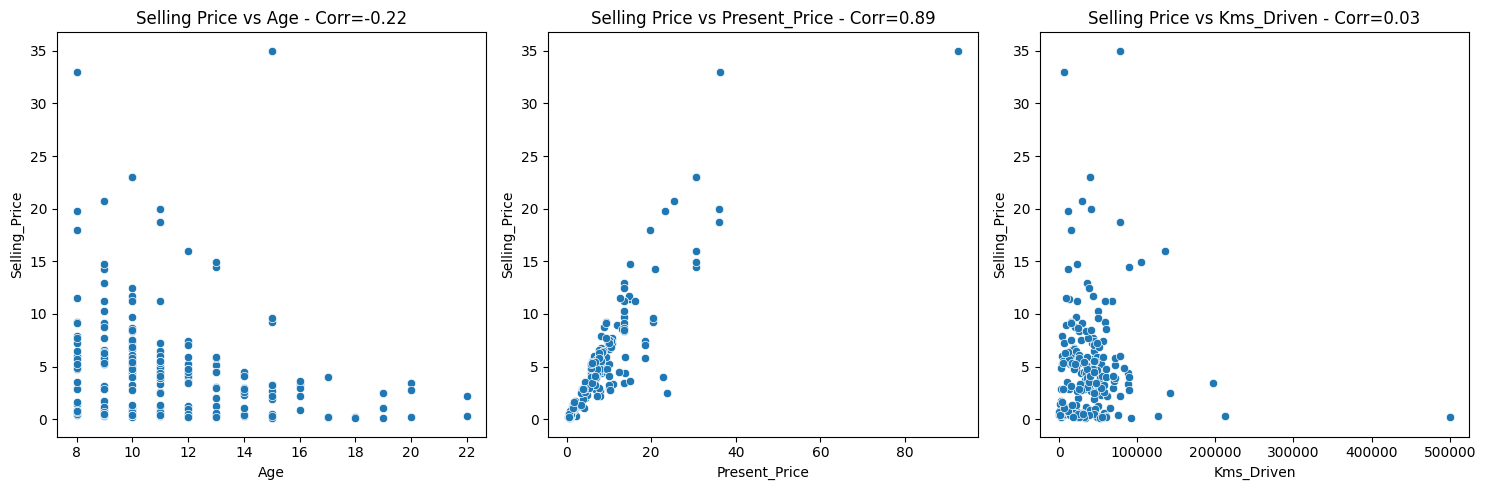

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven']
fig,ax = plt.subplots(1,3,figsize=(15,5))
flatten_ax = ax.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.scatterplot(data=preprocessed_train_df,x=col,y='Selling_Price',ax=ax)
  ax.set_title(f'Selling Price vs {col} - Corr={corr['Selling_Price'][col]:.2f}')

plt.tight_layout()
plt.show()

* Age has a negative correlation with the target variable, but due to the discrete, integer-based nature of the Age feature the trend is not completely visible
* Kms_Driven has a very weak relationship with the target variable (Selling Price), indicating it is not a strong predictor on its own.
*  Present Price displays a strong positive correlation with Selling Price, confirming it as a key driver of car value.
* Clear outliers are visible in all three features.

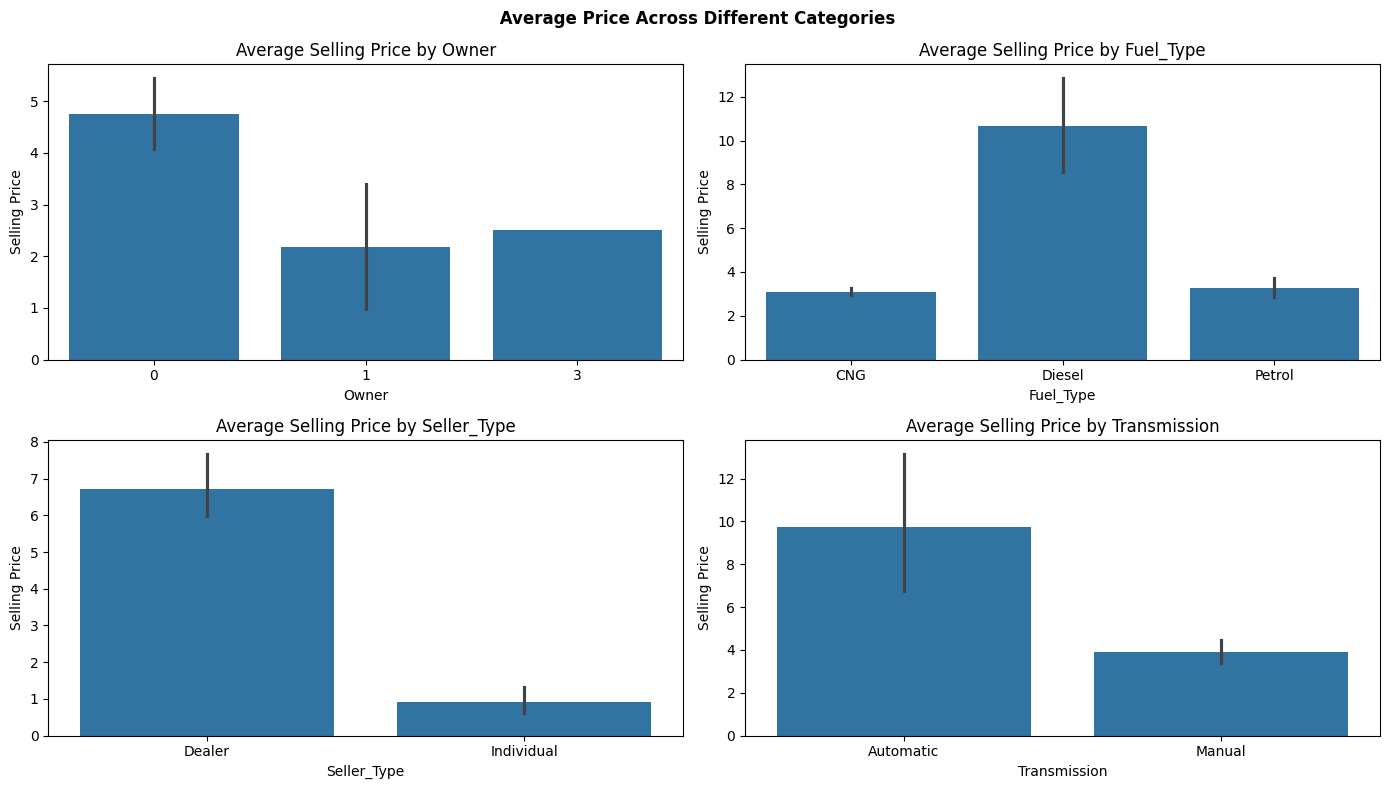

In [ ]:
categorical_cols=['Owner','Fuel_Type', 'Seller_Type', 'Transmission']

fig, ax = plt.subplots(2,2, figsize=(14,8))
plt.suptitle(' Average Price Across Different Categories', weight='bold')
flatten_ax = ax.flatten()

for i , col in enumerate(categorical_cols):
  ax= flatten_ax[i]

  sns.barplot(data=train_df, x=col, y='Selling_Price',estimator='mean', ax=ax)
  ax.set_title(f"Average Selling Price by {col}")
  ax.set_ylabel('Selling Price')
  ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

* Average Selling Price by Owner:

  Surprisingly, cars with 3 previous owners show a slightly higher average selling price than those with 1 previous owner. This is likely due to the very small sample size in the 3-owner category, which makes the mean unreliable.

* Average Selling Price by Fuel Type:

  Diesel cars have a significantly higher average selling price compared to Petrol and CNG vehicles, indicating that fuel type has a strong effect on car value.

* Average Selling Price by Seller Type:

  Cars listed by dealers show an average selling price almost six times higher than those sold by individuals. This could reflect differences in car condition, model availability, or pricing strategies between dealers and private sellers.

* Average Selling Price by Transmission:

  Cars with automatic transmission are more than twice as expensive as manual cars on average, showing a clear preference (and higher market value) for automatic vehicles.

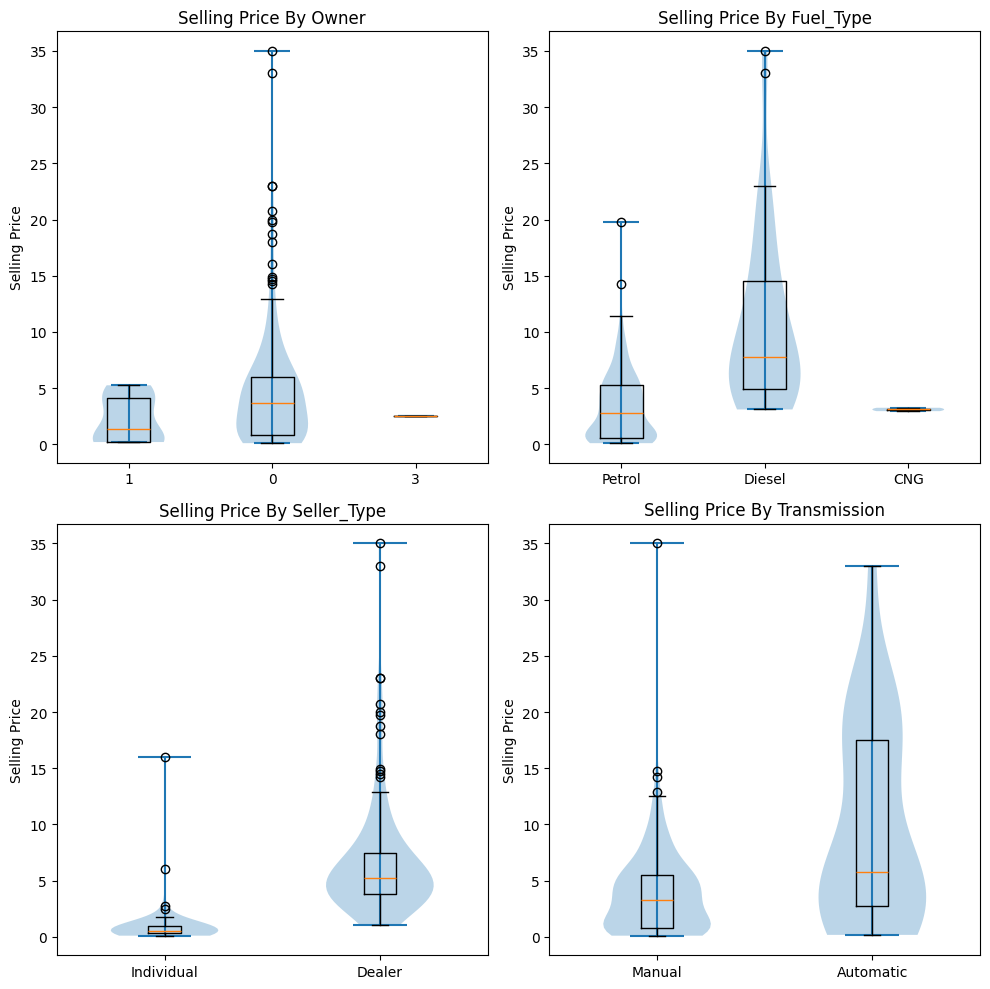

In [ ]:
categorical_cols=['Owner','Fuel_Type', 'Seller_Type', 'Transmission']

fig, ax = plt.subplots(2,2, figsize=(10,10))
flatten_ax = ax.flatten()

for i , col in enumerate(categorical_cols):
  ax = flatten_ax[i]
  categories = train_df[col].unique()
  # Group selling price for each category
  grouped_data = [train_df.Selling_Price[train_df[col] == cat].values for cat in categories]
  ax.violinplot(grouped_data)
  ax.boxplot(grouped_data)
  ax.set_title(f"Selling Price By {col}")
  ax.set_ylabel("Selling Price")
  ax.set_xticklabels(categories)

plt.tight_layout()
plt.show()

* Selling Price vs. Owner:

  The 0-owner category shows several noticeable outliers, indicating unusually high selling prices for a few samples. The 3-owner category has very few data points and shows inconsistent distribution behavior, suggesting that it may need to be removed or treated separately due to its extremely small sample size.

* Selling Price vs. Fuel Type

  Diesel cars clearly have higher selling prices compared to Petrol and CNG vehicles. Outliers are present in both Diesel and Petrol categories. The Petrol distribution shows two visible peaks, suggesting the influence of another variable (such as car brand or model). The CNG category contains very few samples, so it may be appropriate to remove it from modeling or combine it with other categories.

* Selling Price vs. Seller Type:

  Both seller categories exhibit outliers, indicating extreme selling prices in both dealer and individual listings. The spread of values is notably larger for dealer-based sales.

* Selling Price vs. Transmission:

  Both Manual and Automatic transmissions show a bimodal distribution, with two peaks visible in the violin plots. Outliers appear primarily in the Manual category, suggesting a few unusually high-priced manual cars.

## ⮞Multivariate Analysis

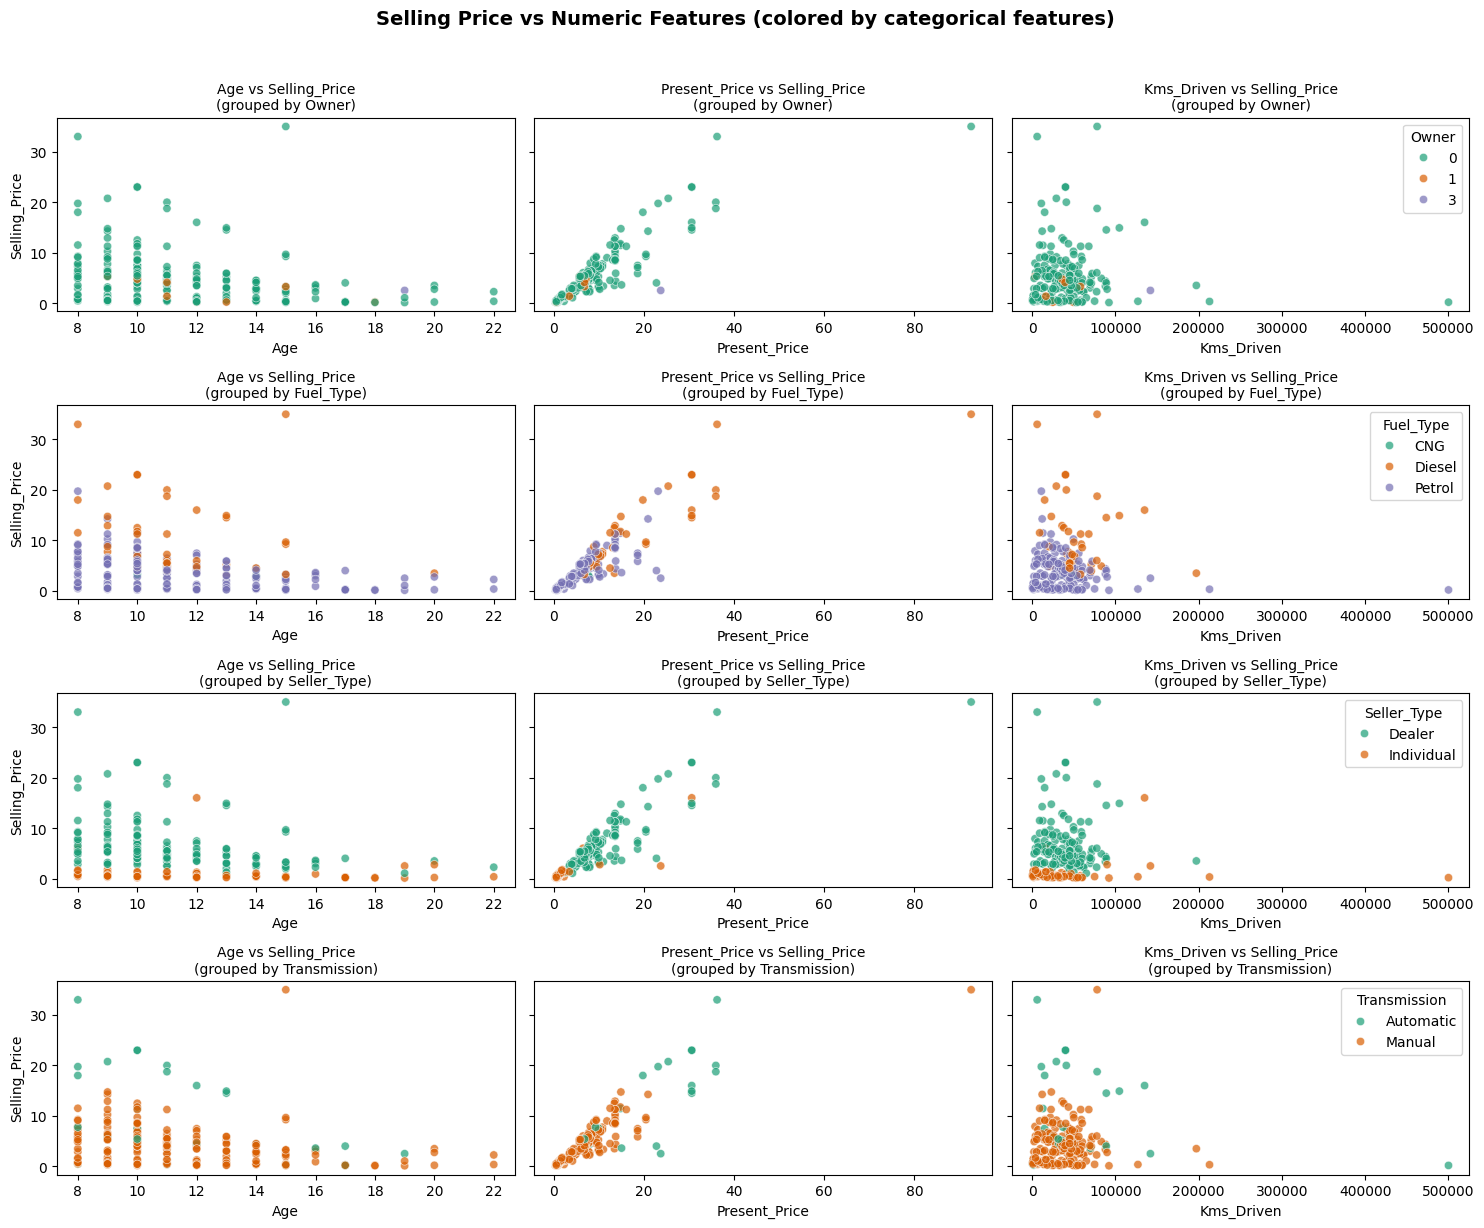

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven']
categorical_cols=['Owner','Fuel_Type', 'Seller_Type', 'Transmission']

fig, axes = plt.subplots(len(categorical_cols), len(numeric_cols), figsize=(15, 12), sharey='row')
plt.suptitle('Selling Price vs Numeric Features (colored by categorical features)', fontsize=14, weight='bold', y=1.02)

for i, cat in enumerate(categorical_cols):          # row index (0..3)
    for j, num in enumerate(numeric_cols):         # col index (0..2)
        ax = axes[i, j]
        sns.scatterplot(
            data=train_df,
            x=num,
            y='Selling_Price',
            hue=cat,
            palette='Dark2',
            alpha=0.7,
            ax=ax,
            legend=(j == 2)   # show legend only in last column to reduce clutter
        )
        ax.set_title(f'{num} vs Selling_Price\n(grouped by {cat})', fontsize=10)

plt.tight_layout()
plt.show()

* **Grouped by Owner:** No clear trend is visible across owner counts; the number of previous owners appears to have little direct effect on selling price.

* **Grouped by Fuel Type:** Diesel cars dominate the higher end of the price range — most of the high-priced points belong to diesel vehicles.

* **Grouped by Seller Type:** There is a clear separation: listings from dealers tend to occupy the upper price range while individual sellers are concentrated at the lower end.

* **Grouped by Transmission:** Mirrors the fuel-type pattern — automatic vehicles are more frequently found among the higher-priced cars.

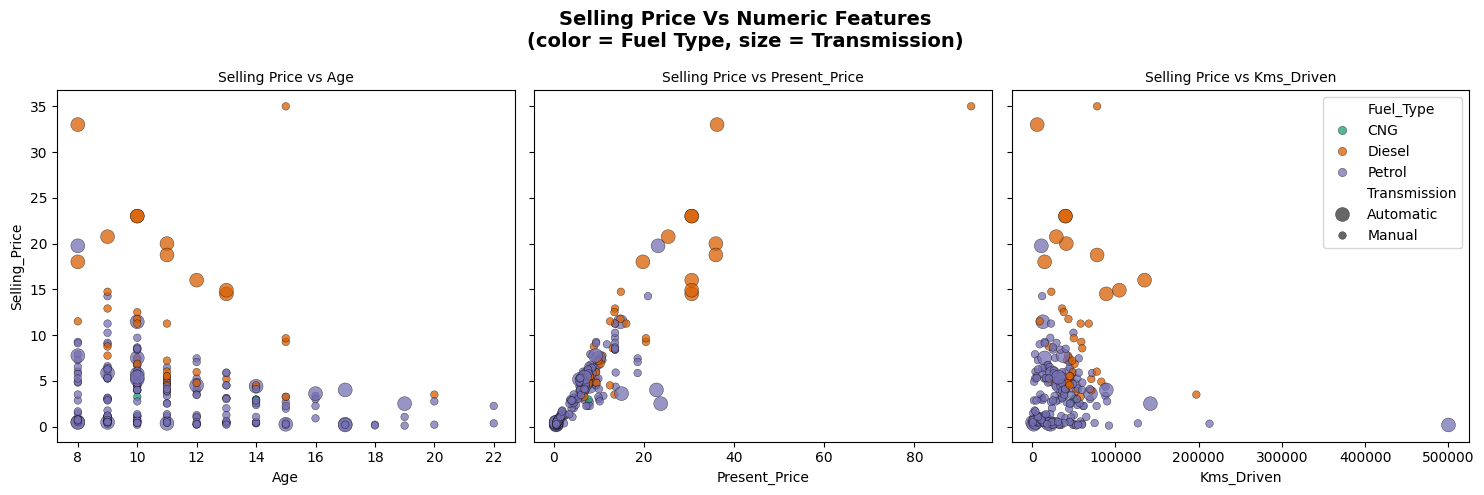

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven']

categorical_hue = 'Fuel_Type'        # colors by fuel type (Petrol/Diesel/CNG)
categorical_size = 'Transmission'    # sizes by transmission (Manual/Automatic)
size_map = {'Manual': 30, 'Automatic': 100}
palette = 'Dark2'

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
plt.suptitle('Selling Price Vs Numeric Features\n(color = Fuel Type, size = Transmission)', fontsize=14, weight='bold')
flatten_ax = ax.flatten()

for i, col in enumerate( numeric_cols):
  ax=flatten_ax[i]
  sns.scatterplot(
        data=train_df,
        x=col,
        y='Selling_Price',
        hue=categorical_hue,
        size=categorical_size,
        sizes=size_map,
        palette=palette,
        alpha=0.75,
        edgecolor='k',
        linewidth=0.3,
        ax=ax,
        legend=(i==2)
    )
  ax.set_title(f'Selling Price vs {col}', fontsize=10)

plt.tight_layout()
plt.show()


* A strong combined effect of Fuel Type and Transmission can be observed from the plots; automatic diesel cars (large markers, orange color) consistently appear at the very high end of the selling price range.
This reflects a premium effect: diesel engines + automatic transmission together correspond to a higher vehicle value.
* Feature loss leads to price drop. A clear pattern can be observed:
When a car loses one high-value feature, for example,
Diesel → Petrol or Automatic → Manual, its selling price drops noticeably.

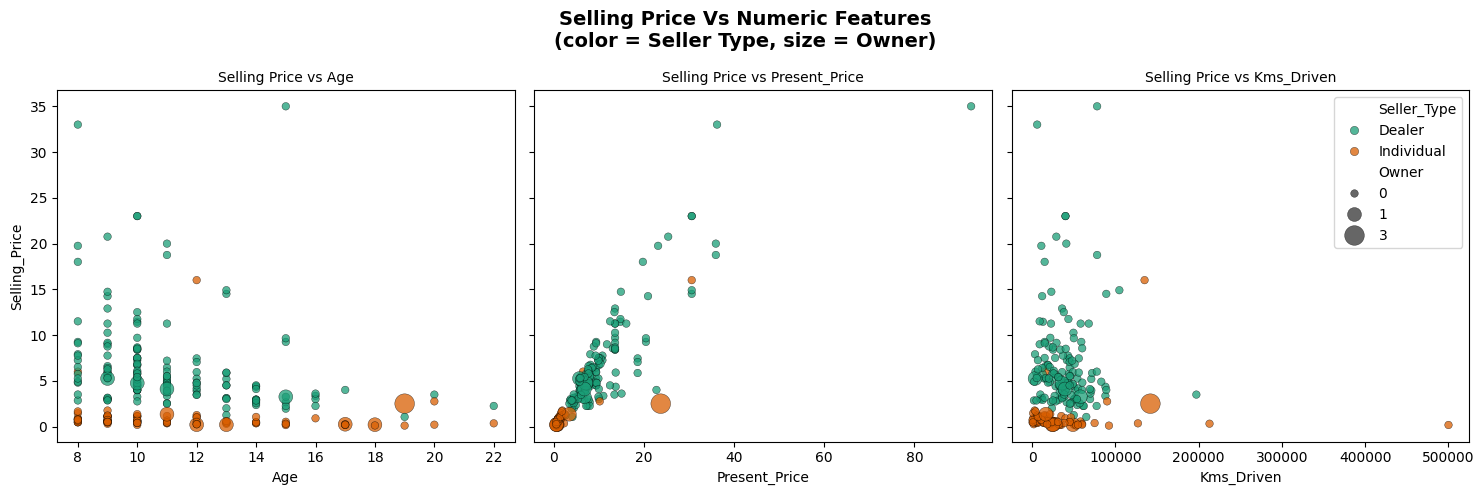

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven']

categorical_hue = 'Seller_Type'
categorical_size = 'Owner'
size_map = {0: 30, 1: 100, 3:200}
palette = 'Dark2'

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
plt.suptitle('Selling Price Vs Numeric Features\n(color = Seller Type, size = Owner)', fontsize=14, weight='bold')
flatten_ax = ax.flatten()

for i, col in enumerate( numeric_cols):
  ax=flatten_ax[i]
  sns.scatterplot(
        data=train_df,
        x=col,
        y='Selling_Price',
        hue=categorical_hue,
        size=categorical_size,
        sizes=size_map,
        palette=palette,
        alpha=0.75,
        edgecolor='k',
        linewidth=0.3,
        ax=ax,
        legend=(i==2)
    )
  ax.set_title(f'Selling Price vs {col}', fontsize=10)

plt.tight_layout()
plt.show()


Dealer listings dominate the higher price range regardless of ownership count.

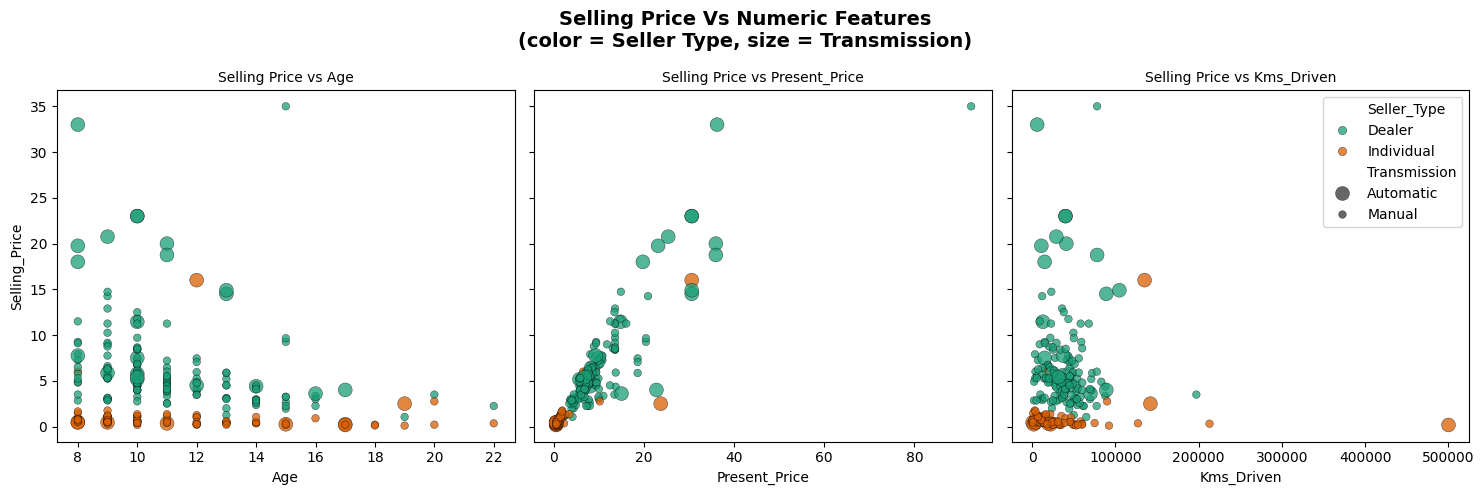

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven']

categorical_hue = 'Seller_Type'
categorical_size = 'Transmission'
size_map = {'Manual': 30, 'Automatic': 100}
palette = 'Dark2'

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
plt.suptitle('Selling Price Vs Numeric Features\n(color = Seller Type, size = Transmission)', fontsize=14, weight='bold')
flatten_ax = ax.flatten()

for i, col in enumerate( numeric_cols):
  ax=flatten_ax[i]
  sns.scatterplot(
        data=train_df,
        x=col,
        y='Selling_Price',
        hue=categorical_hue,
        size=categorical_size,
        sizes=size_map,
        palette=palette,
        alpha=0.75,
        edgecolor='k',
        linewidth=0.3,
        ax=ax,
        legend=(i==2)
    )
  ax.set_title(f'Selling Price vs {col}', fontsize=10)

plt.tight_layout()
plt.show()


Dealer–automatic combinations appear at higher price levels, and individual–manual combinations cluster at lower prices.

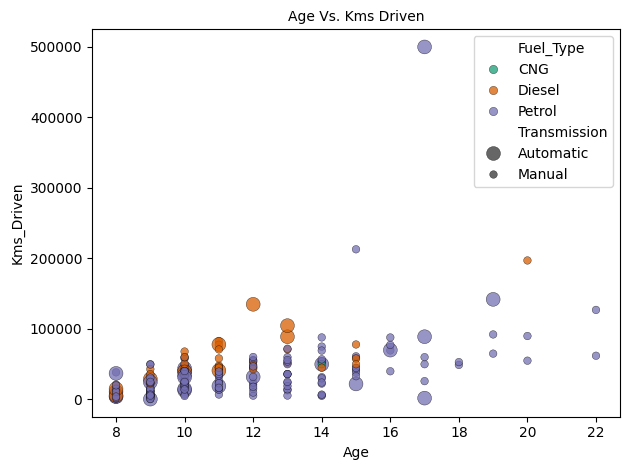

In [ ]:
sns.scatterplot(
        data=train_df,
        x='Age',
        y='Kms_Driven',
        hue='Fuel_Type',
        size='Transmission',
        sizes={'Manual': 30, 'Automatic': 100},
        palette='Dark2',
        alpha=0.75,
        edgecolor='k',
        linewidth=0.3
    )

plt.title(f'Age Vs. Kms Driven', fontsize=10)
plt.tight_layout()
plt.show()


* Generally, the milage increases with the increase in age.
* Diesel cars are generally newer.
Most diesel vehicles fall below 15 years of age, while petrol cars span a wider age range, ranging from 8 to 22 years old. This suggests a more diverse mix of older and newer petrol vehicles in the dataset.
* Automatic cars follow a similar trend to diesel cars.
Automatic vehicles (larger markers) also cluster in the newer age range, indicating that automatic transmission is more common in newer cars.
* Older cars are mostly petrol and manual
Points in the 18–22 year age range are almost exclusively petrol + manual, showing that older vehicles in the dataset tend not to be diesel or automatic.

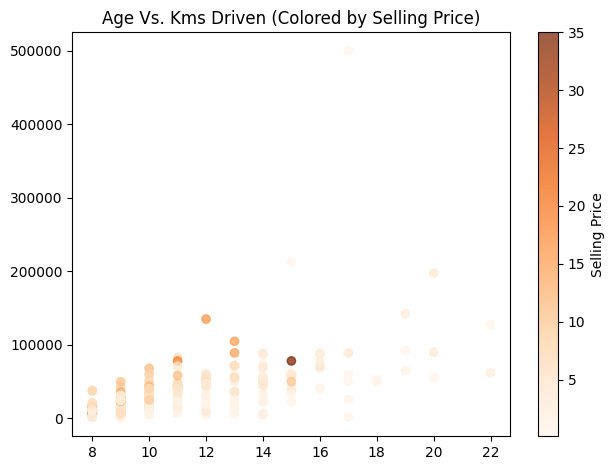

In [ ]:
plt.scatter(
        train_df['Age'],
        train_df['Kms_Driven'],
        c=train_df['Selling_Price'],
        #s=train_df['Transmission'].map({'Manual': 30, 'Automatic': 100}),
        cmap='Oranges',
        alpha=0.75
        )
cbar = plt.colorbar()
cbar.set_label("Selling Price")
plt.title(f'Age Vs. Kms Driven (Colored by Selling Price)', fontsize=12)
plt.tight_layout()
plt.show()

Older cars with higher mileage tend to have a lower price, though substantial price variation among newer vehicles highlights the influence of additional features beyond usage-related factors.

# 🔶Outliers


## ⮞Univariate Analysis

### ▸Numerical Features

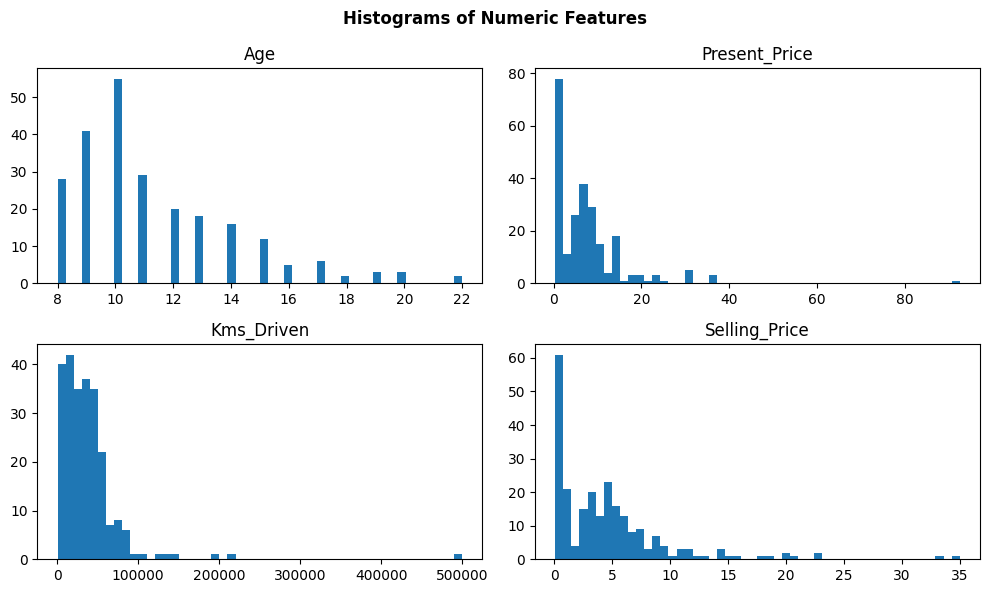

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven', 'Selling_Price']
fig, ax = plt.subplots(2,2, figsize=(10,6))
plt.suptitle('Histograms of Numeric Features', weight='bold')
flatten_ax = ax.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  ax.hist(preprocessed_train_df[col], bins=50)
  ax.set_title(col)

plt.tight_layout()
plt.show()

🔍 Outlier Analysis and Handling

all numeric features in the dataset exhibit right-skewed distributions, indicating the presence of outliers in the upper range.
Applying feature transformations can help normalize these distributions and reduce the influence of outliers on the model.

For right-skewed features, common transformation techniques include:
* Logarithmic Transformation
* Box–Cox Transformation
* Yeo–Johnson Transformation
* Quantile Transformation

In this step, we experiment with these transformers to determine which method produces a more normalized and stable distribution for our data.

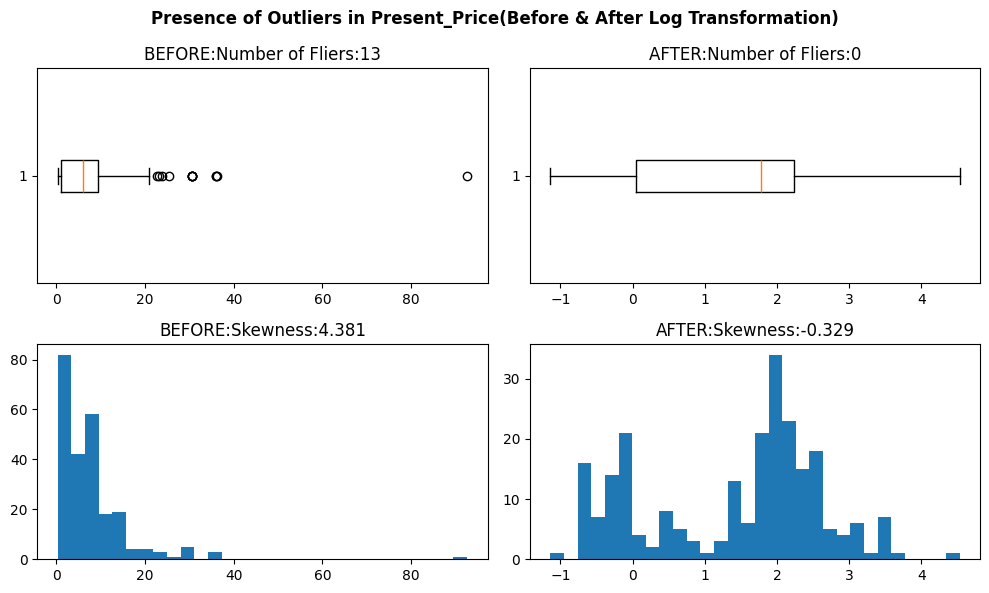

In [ ]:
# Applying log-transform on Present_Price
fig, ax = plt.subplots(2,2,figsize=(10,6))
plt.suptitle('Presence of Outliers in Present_Price(Before & After Log Transformation)', weight='bold')


# Box Plot of Present_price before applying log-transformation
fliers = ax[0,0].boxplot(preprocessed_train_df['Present_Price'], vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,0].set_title(f'BEFORE:Number of Fliers:{len(fliers)}')

# Histogram of Present_price before applying log-transformation
skewness_orig = skew(preprocessed_train_df.Present_Price)
ax[1,0].hist(preprocessed_train_df['Present_Price'], 30)
ax[1,0].set_title(f'BEFORE:Skewness:{skewness_orig:.3f}')

# Box Plot of Present_price after applying log-transformation
function_transformer = FunctionTransformer(lambda x:np.log(x))
Log_Present_Price = function_transformer.fit_transform(preprocessed_train_df['Present_Price'])
log_fliers = ax[0,1].boxplot(Log_Present_Price, vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,1].set_title(f'AFTER:Number of Fliers:{len(log_fliers)}')

# Histogram of Present_price after applying log-transformation
skewness_log = skew(Log_Present_Price)
ax[1,1].hist(Log_Present_Price, 30)
ax[1,1].set_title(f'AFTER:Skewness:{skewness_log:.3f}')

plt.tight_layout()
plt.show()

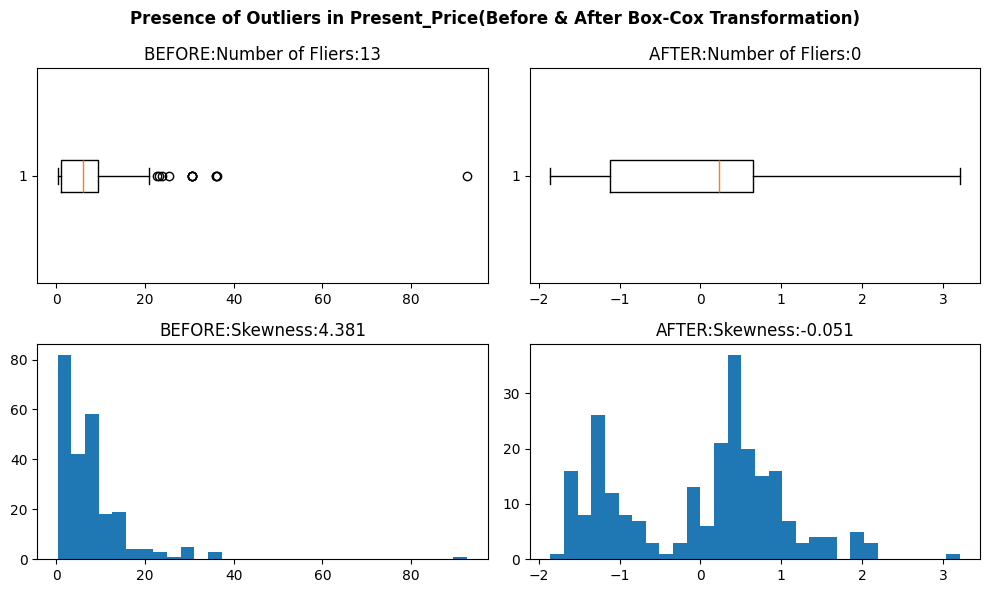

In [ ]:
# Applying Box-Cox-transform on Present_Price
fig, ax = plt.subplots(2,2,figsize=(10,6))
plt.suptitle('Presence of Outliers in Present_Price(Before & After Box-Cox Transformation)', weight='bold')


# Box Plot of Present_price before applying box-cox-transformation
fliers = ax[0,0].boxplot(preprocessed_train_df['Present_Price'], vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,0].set_title(f'BEFORE:Number of Fliers:{len(fliers)}')

# Histogram of Present_price before applying box-cox-transformation
skewness_orig = skew(preprocessed_train_df.Present_Price)
ax[1,0].hist(preprocessed_train_df['Present_Price'], 30)
ax[1,0].set_title(f'BEFORE:Skewness:{skewness_orig:.3f}')

# Box Plot of Present_price after applying box-cox-transformation
boxcox = PowerTransformer("box-cox")
BC_Present_Price = boxcox.fit_transform(preprocessed_train_df[['Present_Price']])
bc_fliers = ax[0,1].boxplot(BC_Present_Price, vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,1].set_title(f'AFTER:Number of Fliers:{len(bc_fliers)}')

# Histogram of Present_price after applying box-cox-transformation
skewness_bc = skew(BC_Present_Price)[0]
ax[1,1].hist(BC_Present_Price, 30)
ax[1,1].set_title(f'AFTER:Skewness:{skewness_bc:.3f}')

plt.tight_layout()
plt.show()

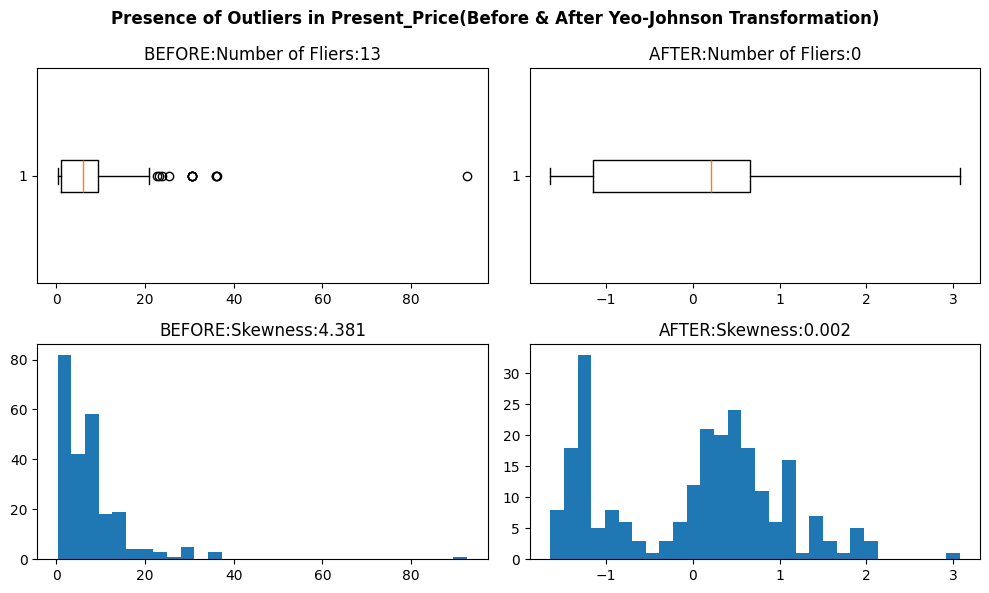

In [ ]:
# Applying Yeo-Johnson-transform on Present_Price
fig, ax = plt.subplots(2,2,figsize=(10,6))
plt.suptitle('Presence of Outliers in Present_Price(Before & After Yeo-Johnson Transformation)', weight='bold')


# Box Plot of Present_price before applying Yeo-Johnson-transformation
fliers = ax[0,0].boxplot(preprocessed_train_df['Present_Price'], vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,0].set_title(f'BEFORE:Number of Fliers:{len(fliers)}')

# Histogram of Present_price before applying Yeo-Johnson-transformation
skewness_orig = skew(preprocessed_train_df.Present_Price)
ax[1,0].hist(preprocessed_train_df['Present_Price'], 30)
ax[1,0].set_title(f'BEFORE:Skewness:{skewness_orig:.3f}')

# Box Plot of Present_price after applying Yeo-Johnson-transformation
yeoj = PowerTransformer('yeo-johnson')
YJ_Present_Price = yeoj.fit_transform(preprocessed_train_df[['Present_Price']])
# YJ_Present_Price, lambda_ = yeojohnson(preprocessed_train_df['Present_Price'])
yj_fliers = ax[0,1].boxplot(YJ_Present_Price, vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,1].set_title(f'AFTER:Number of Fliers:{len(yj_fliers)}')

# Histogram of Present_price after applying Yeo-Johnson-transformation
skewness_yj = skew(YJ_Present_Price)[0]
ax[1,1].hist(YJ_Present_Price, 30)
ax[1,1].set_title(f'AFTER:Skewness:{skewness_yj:.3f}')

plt.tight_layout()
plt.show()

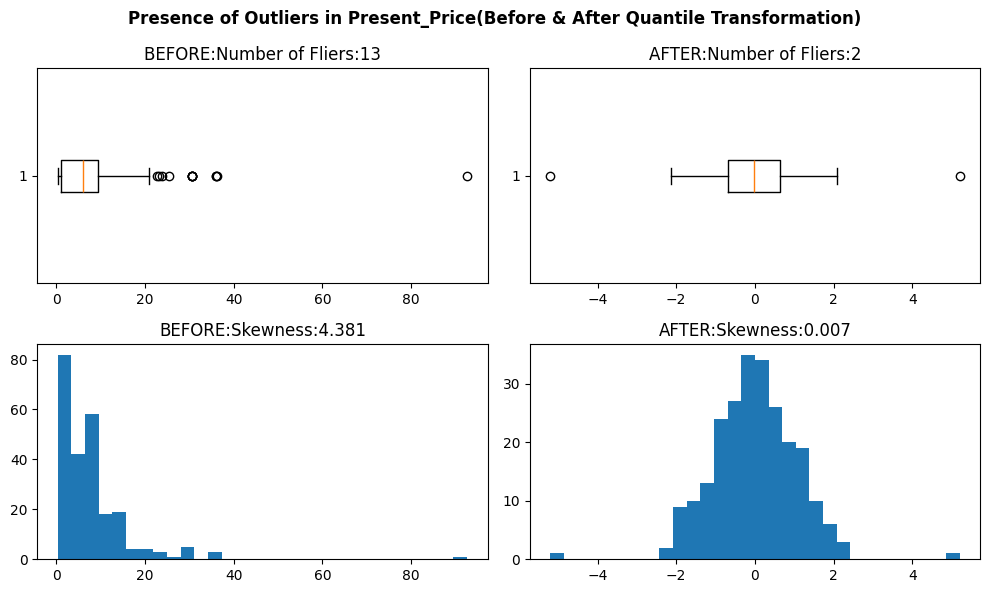

In [ ]:
# Applying Quantile transformer on Present_Price   # To Be Completed... #
fig, ax = plt.subplots(2,2,figsize=(10,6))
plt.suptitle('Presence of Outliers in Present_Price(Before & After Quantile Transformation)', weight='bold')


# Box Plot of Present_price before applying Quantile-transformation
fliers = ax[0,0].boxplot(preprocessed_train_df['Present_Price'], vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,0].set_title(f'BEFORE:Number of Fliers:{len(fliers)}')

# Histogram of Present_price before applying Quantile-transformation
skewness_orig = skew(preprocessed_train_df.Present_Price)
ax[1,0].hist(preprocessed_train_df['Present_Price'], 30)
ax[1,0].set_title(f'BEFORE:Skewness:{skewness_orig:.3f}')

# Box Plot of Present_price after applying Quantile-transformation
qt = QuantileTransformer(output_distribution='normal', n_quantiles=50)
QT_Present_Price = qt.fit_transform(preprocessed_train_df[['Present_Price']])
qt_fliers = ax[0,1].boxplot(QT_Present_Price, vert=False, whis=1.5)['fliers'][0].get_ydata()
ax[0,1].set_title(f'AFTER:Number of Fliers:{len(qt_fliers)}')

# Histogram of Present_price after applying Quantile-transformation
skewness_qt = skew(QT_Present_Price)[0]
ax[1,1].hist(QT_Present_Price, 30)
ax[1,1].set_title(f'AFTER:Skewness:{skewness_qt:.3f}')

plt.tight_layout()
plt.show()

For the Present_Price feature, all transformations significantly reduced skewness and eliminated extreme outliers. However, among all, the Yeo-Johnson transformer shows better results and handles skewness more effectively than the other transformers. So, we apply the Yeo-Johnson to the rest of the right-skewed features.

Although the Quantile Transformer produced the most visually Gaussian distribution, it was not selected for the final preprocessing pipeline. Quantile-based transformations reshape the empirical distribution and may distort relative feature magnitudes, particularly in small datasets. Given the regression-oriented nature of the task, the Yeo–Johnson transformation was preferred as the final solution.

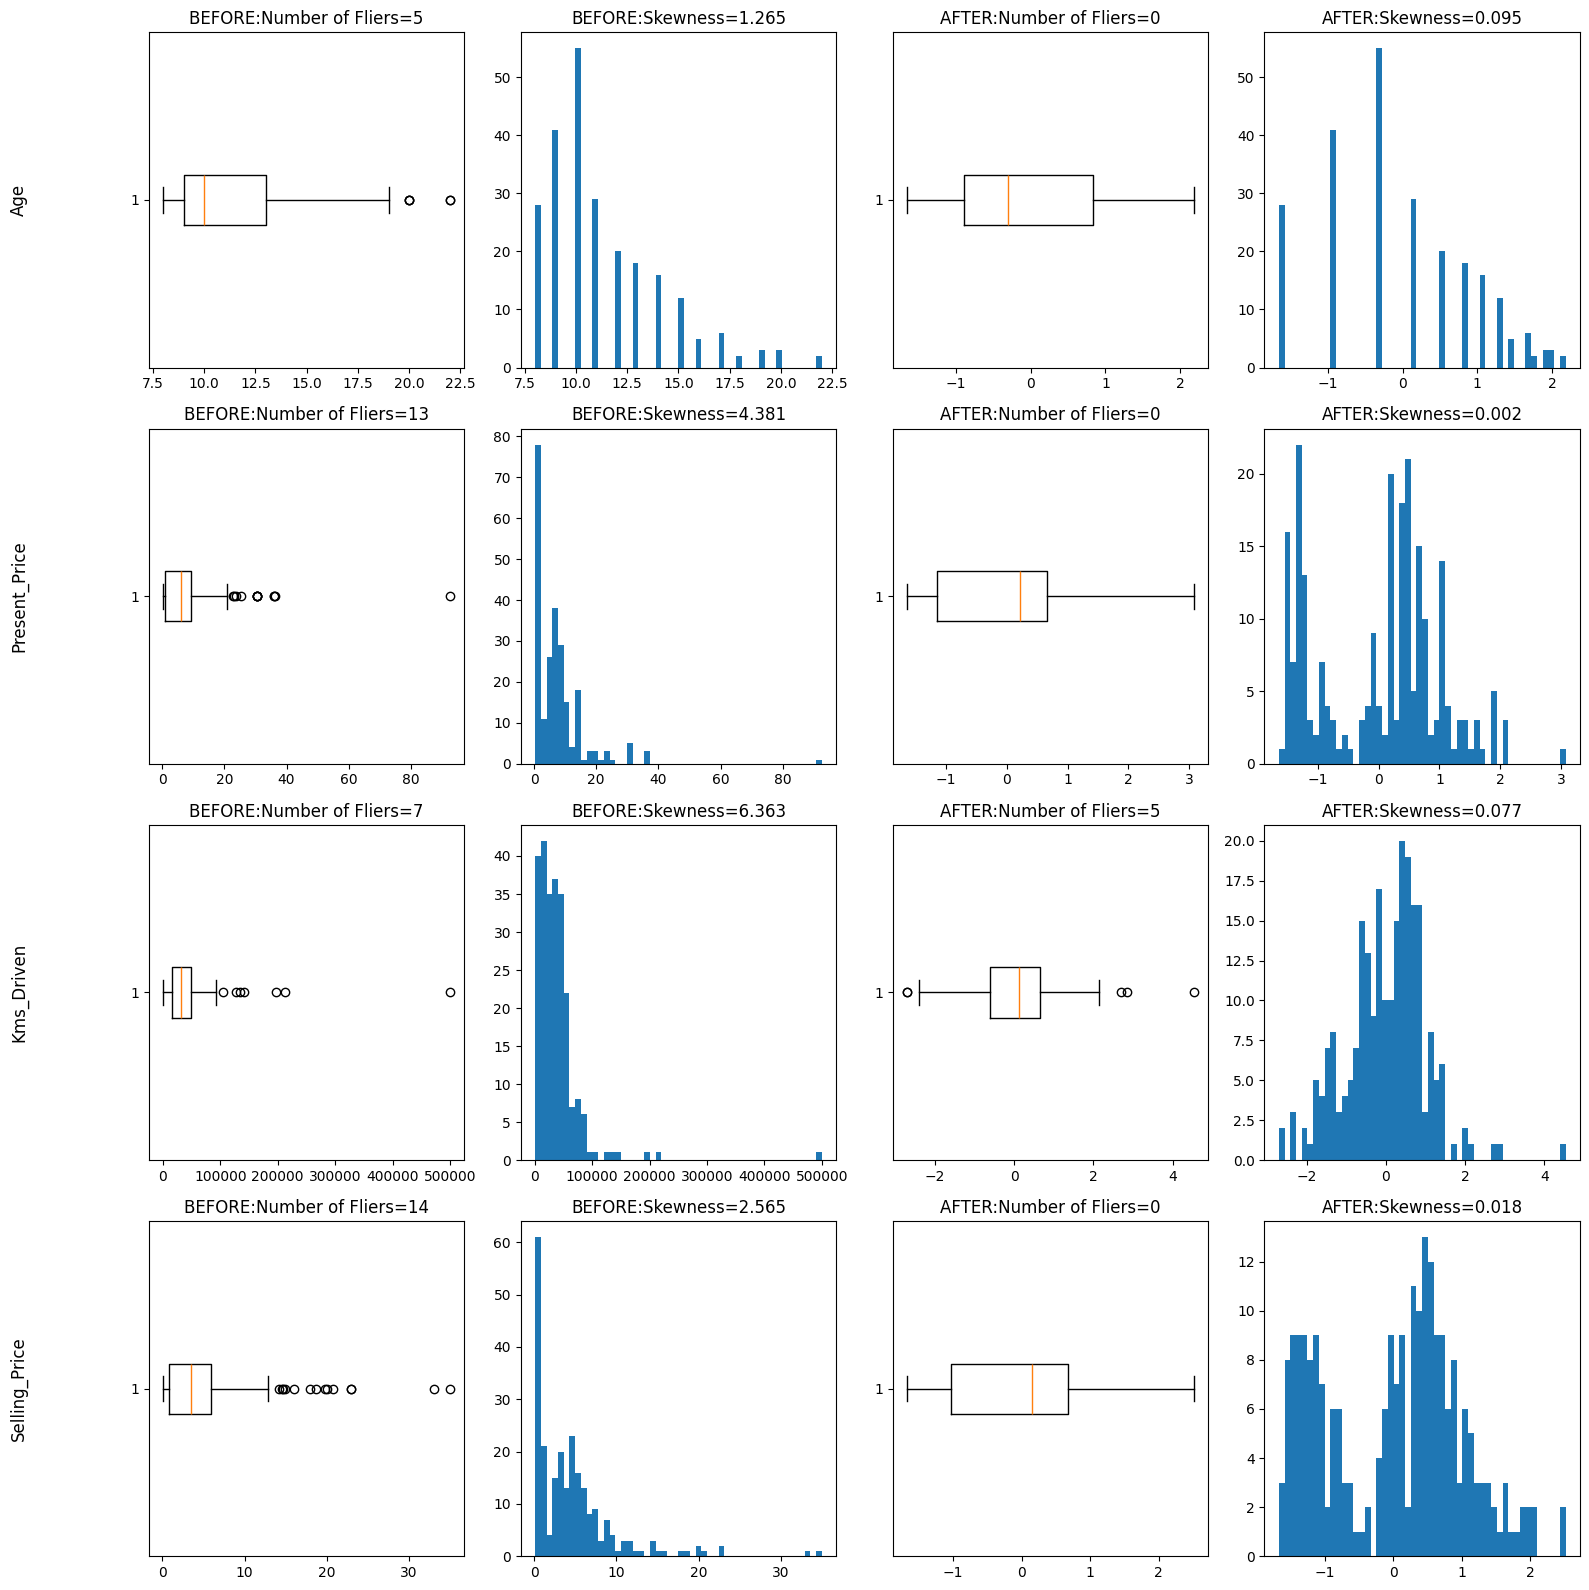

In [ ]:
# Feature Transform using Yeo-Johnson Transformer:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven', 'Selling_Price']

fig, ax = plt.subplots(len(numeric_cols), 4, figsize=(16,4*len(numeric_cols)))
for i, col in enumerate(numeric_cols):
  ax[i, 0].set_ylabel(col, rotation=90, labelpad=80, fontsize=12, va='center')

  # box plot of the original feature
  fliers = ax[i,0].boxplot(preprocessed_train_df[col], vert=False, whis=1.5)['fliers'][0].get_ydata()
  ax[i,0].set_title(f'BEFORE:Number of Fliers={len(fliers)}')

  # Histogram of original feature
  skewness_orig = skew(preprocessed_train_df[col])
  ax[i,1].hist(preprocessed_train_df[col], 50)
  ax[i,1].set_title(f'BEFORE:Skewness={skewness_orig:.3f}')

  # box plot of yeo-johnson-transformed feature
  yeoj = PowerTransformer('yeo-johnson')
  transformed_feature = yeoj.fit_transform(preprocessed_train_df[[col]])
  yj_fliers = ax[i,2].boxplot(transformed_feature, vert=False, whis=1.5)['fliers'][0].get_ydata()
  ax[i,2].set_title(f'AFTER:Number of Fliers={len(yj_fliers)}')

  # Histogram of yeo-johnson-transformed feature
  skewness_yj = skew(transformed_feature)[0]
  ax[i,3].hist(transformed_feature, 50)
  ax[i,3].set_title(f'AFTER:Skewness={skewness_yj:.3f}')

plt.tight_layout()
plt.show()

In [ ]:
# Make a copy of the dataset to apply feature transformation
preprocessed_train_df_2 = preprocessed_train_df.copy()

In [ ]:
# Apply feature transformation on numeric columns
feature_cols = ['Age', 'Present_Price', 'Kms_Driven']
target_col = 'Selling_Price'

yeoj_x = PowerTransformer(method='yeo-johnson')
preprocessed_train_df[feature_cols] = yeoj_x.fit_transform(preprocessed_train_df[feature_cols])
print(f'Feature Lambdas: {yeoj_x.lambdas_}')

yeoj_y = PowerTransformer(method='yeo-johnson')
preprocessed_train_df[[target_col]] = yeoj_y.fit_transform(preprocessed_train_df[[target_col]])
print(f'Target Lambdas: {yeoj_y.lambdas_}')


Feature Lambdas: [-1.57341955 -0.00751726  0.2516246 ]
Target Lambdas: [-0.07796369]


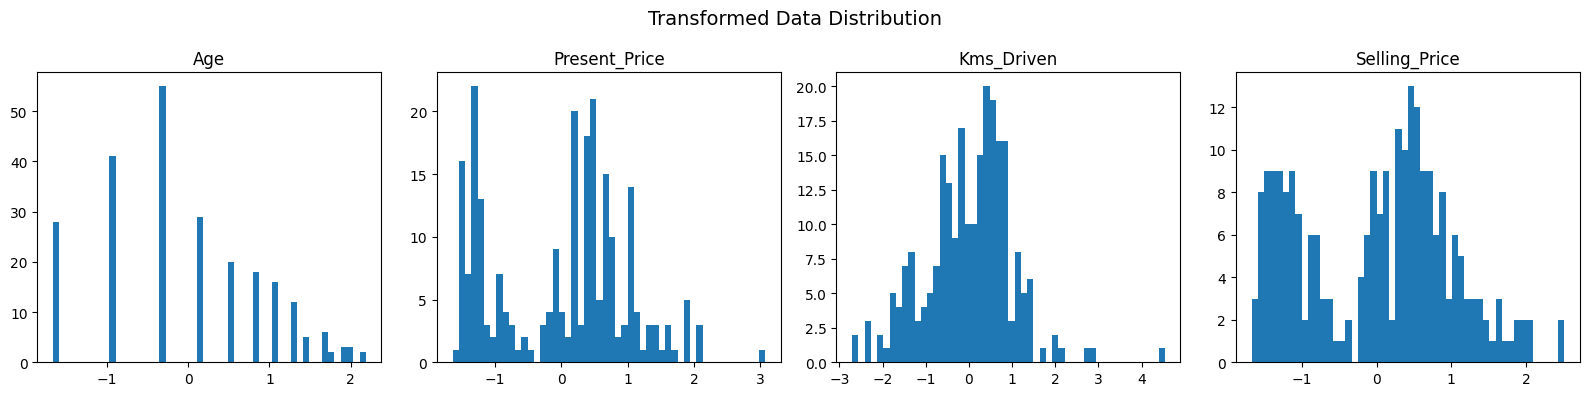

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven', 'Selling_Price']

fig,ax = plt.subplots(1,4, figsize=(16,4))
flatten_ax = ax.flatten()
plt.suptitle('Transformed Data Distribution', fontsize=14)

for i,col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  ax.hist(preprocessed_train_df[col],50)
  ax.set_title(col)

plt.tight_layout()
plt.show()

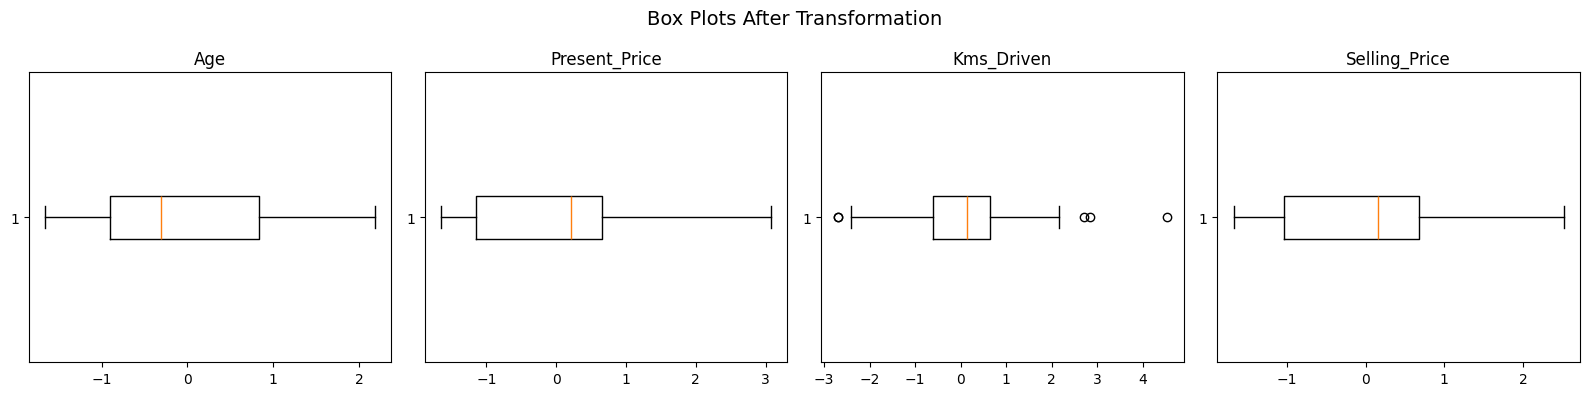

In [ ]:
fig,ax = plt.subplots(1,4, figsize=(16,4))
flatten_ax = ax.flatten()
plt.suptitle('Box Plots After Transformation', fontsize=14)

for i,col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  ax.boxplot(preprocessed_train_df[col], vert=False)
  ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Outliers in Kms_Driven
desc = preprocessed_train_df['Kms_Driven'].describe()
Q1 = desc['25%']
Q3 = desc['75%']
IQR = Q3 - Q1
lower_cap = Q1 - 1.5 * IQR
upper_cap = Q3 + 1.5 * IQR

flags = (preprocessed_train_df['Kms_Driven'] < lower_cap) | (preprocessed_train_df['Kms_Driven'] > upper_cap)
print(flags.sum())
upper_cap, lower_cap

5


(np.float64(2.5288762791747077), np.float64(-2.5018406869039636))

Text(2.5288762791747077, 19.5, '2.53')

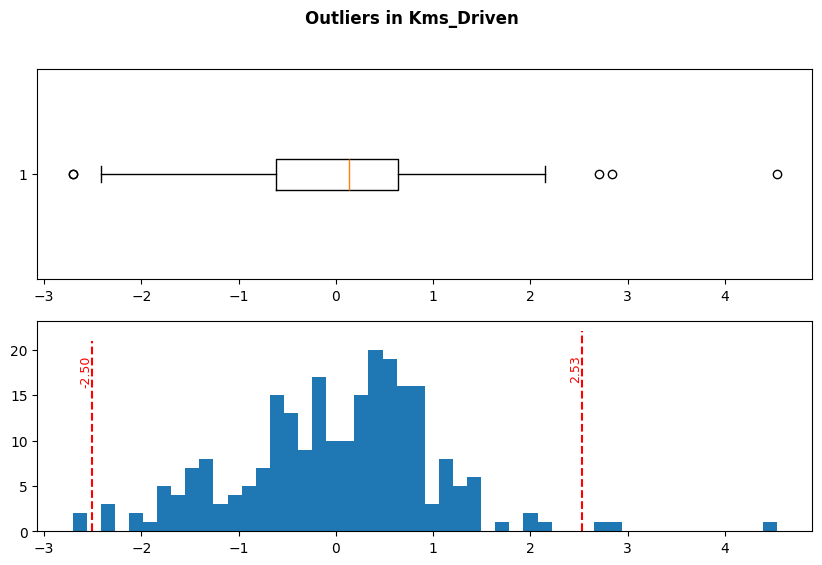

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(10,6))
plt.suptitle('Outliers in Kms_Driven', weight='bold')

# Box Plot
ax[0].boxplot(preprocessed_train_df['Kms_Driven'], vert=False)

# Histogram
ax[1].hist(preprocessed_train_df['Kms_Driven'],50)
ax[1].vlines(lower_cap, ymin=plt.ylim()[0], ymax=plt.ylim()[1], color='r', ls='--')
ax[1].vlines(upper_cap, ymin=plt.ylim()[0], ymax=plt.ylim()[1], color='r', ls='--')
ax[1].text(lower_cap, 19.5, f"{lower_cap:.2f}", color='red', fontsize=9, rotation=90, va='top', ha='right')
ax[1].text(upper_cap, 19.5, f"{upper_cap:.2f}", color='red', fontsize=9, rotation=90, va='top', ha='right')

In [ ]:
# dropping the outliers(outside the range of caps)
flags = (preprocessed_train_df['Kms_Driven'] < lower_cap) | (preprocessed_train_df['Kms_Driven'] > upper_cap)
print(f'Number of samples before dropping the outliers:{preprocessed_train_df.shape[0]}')
print(f'Number of outliers to drop:{flags.sum()}')

# drop
preprocessed_train_df = preprocessed_train_df[~flags]

print(f'Number of samples after dropping the outliers:{preprocessed_train_df.shape[0]}')

Number of samples before dropping the outliers:240
Number of outliers to drop:5
Number of samples after dropping the outliers:235


Despite the transformation, a small number of extreme values remained in the Kms_Driven feature. Given that mileage represents vehicle usage intensity and may contain atypical or noisy records, IQR-based caps were computed on the transformed feature. Only 5 samples (≈2% of the data) fell outside the acceptable range and were removed.

### ▸Categorical Features

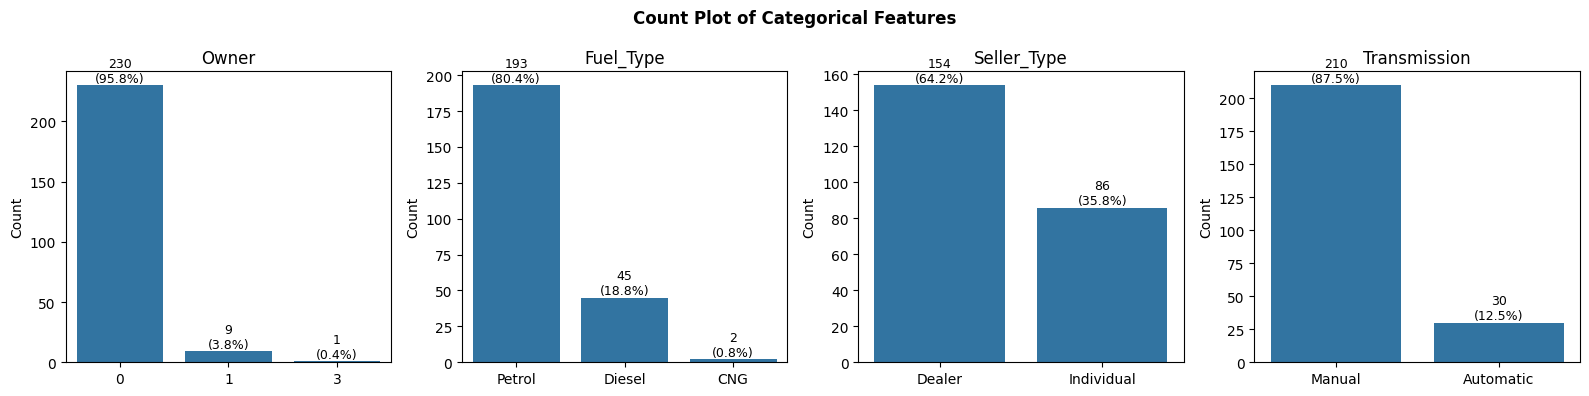

In [ ]:
categorical_cols=['Owner','Fuel_Type', 'Seller_Type', 'Transmission']

fig, ax = plt.subplots(1,4, figsize=(16,4))
plt.suptitle('Count Plot of Categorical Features', weight='bold')
flatten_ax = ax.flatten()

for i , col in enumerate(categorical_cols):
  ax= flatten_ax[i]

  # order by frequency (descending)
  vc = train_df[col].value_counts()
  order = vc.index.tolist()
  # countplot (bars = counts)
  sns.countplot(data=train_df, x=col, order=order, ax=ax)

  # annotate counts and percentages above bars
  for p in ax.patches:
      count = int(p.get_height())
      pct = count / len(train_df) * 100
      x = p.get_x() + p.get_width() / 2
      y = p.get_height()
      ax.text(x, y + len(train_df)*0.001, f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

  ax.set_title(col)
  ax.set_xlabel('')
  ax.set_ylabel('Count')
  ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The Owner feature is highly imbalanced, with the vast majority of cars having Owner = 0. To reduce sparsity and improve model stability, owner categories greater than zero will be consolidated into a single group.

In [ ]:
#Combine the two columns of Owner_1 & Owner_3
preprocessed_train_df.loc[:, 'Owner_Type'] = (
    preprocessed_train_df['Owner_0'].apply(lambda x: 'OneOrMoreOwners' if x == 0 else '0Owners')
)

# Drop old dummy variables
preprocessed_train_df = preprocessed_train_df.drop(columns=['Owner_0', 'Owner_1', 'Owner_3'])

# One-hot encode the new consolidated variable
preprocessed_train_df = pd.get_dummies(preprocessed_train_df, columns=['Owner_Type'], drop_first=True)

# Force dummy column to float64
dummy_cols = [col for col in preprocessed_train_df.columns if col.startswith("Owner_Type_")]
preprocessed_train_df[dummy_cols] = preprocessed_train_df[dummy_cols].astype("float64")
preprocessed_train_df.head()

,Age,Present_Price,Kms_Driven,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Selling_Price,Owner_Type_OneOrMoreOwners
184,1.647696,-1.327814,-0.075399,0.0,0.0,1.0,1.0,1.0,-1.499001,1.0
132,-1.658035,-1.206284,-1.730534,0.0,0.0,1.0,1.0,1.0,-1.048082,0.0
194,1.647696,-1.304309,0.671732,0.0,0.0,1.0,1.0,1.0,-1.554517,0.0
75,-0.310079,0.341895,0.281049,0.0,0.0,1.0,0.0,1.0,0.272894,0.0
111,-0.897484,-0.927620,-1.081203,0.0,0.0,1.0,1.0,1.0,-0.777987,0.0


In [ ]:
# Move target variable (Selling_Price) to the last column
cols = [col for col in preprocessed_train_df.columns if col != 'Selling_Price']
cols.append('Selling_Price')
preprocessed_train_df = preprocessed_train_df[cols]

In [ ]:
# Remove Fuel_Type_CNG due to extremely low sample count
preprocessed_train_df = preprocessed_train_df.drop(columns=['Fuel_Type_CNG'])

# Remove 'Fuel_Type_Petrol' feature because Fuel_Type_Diesel is 0 and 1 (0 mean Fuel_Type_Petrol and 1 mean Fuel_Type_Diesel)
preprocessed_train_df = preprocessed_train_df.drop(columns=['Fuel_Type_Petrol'])
preprocessed_train_df.head()

,Age,Present_Price,Kms_Driven,Fuel_Type_Diesel,Seller_Type_Individual,Transmission_Manual,Owner_Type_OneOrMoreOwners,Selling_Price
184,1.647696,-1.327814,-0.075399,0.0,1.0,1.0,1.0,-1.499001
132,-1.658035,-1.206284,-1.730534,0.0,1.0,1.0,0.0,-1.048082
194,1.647696,-1.304309,0.671732,0.0,1.0,1.0,0.0,-1.554517
75,-0.310079,0.341895,0.281049,0.0,0.0,1.0,0.0,0.272894
111,-0.897484,-0.927620,-1.081203,0.0,1.0,1.0,0.0,-0.777987


## ⮞Bivariate Analysis

In [ ]:
# Make a copy of the dataset to later examine the model's performance with and without the outliers
clean_train_df = preprocessed_train_df.copy()

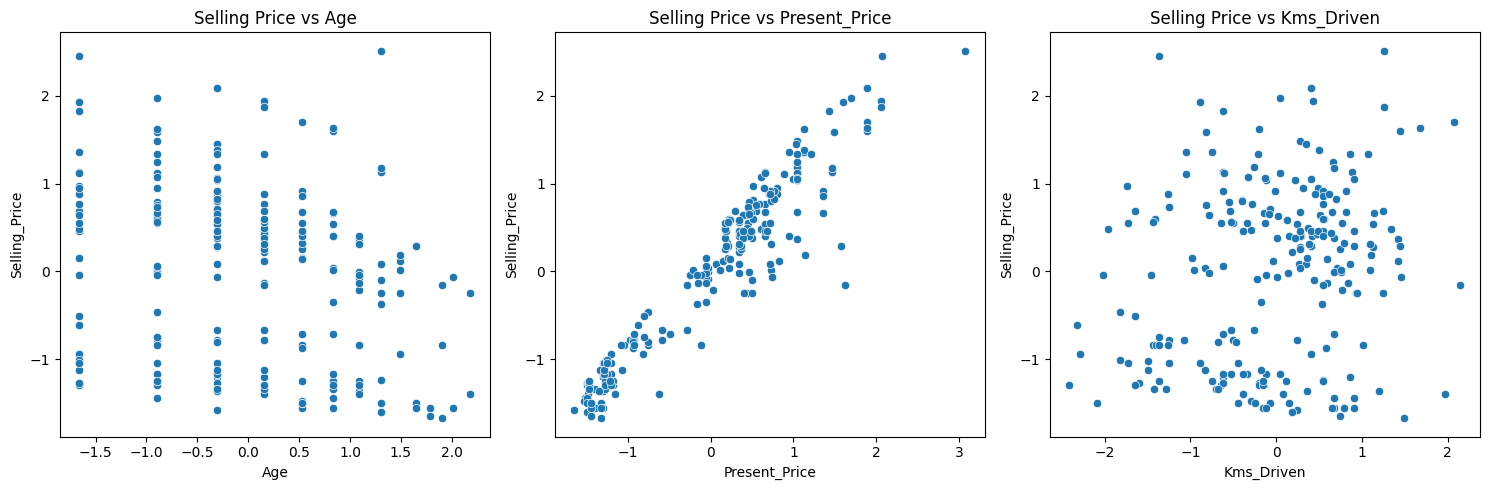

In [ ]:
numeric_cols = ['Age', 'Present_Price', 'Kms_Driven']
fig,ax = plt.subplots(1,3,figsize=(15,5))
flatten_ax = ax.flatten()

for i, col in enumerate(numeric_cols):
  ax = flatten_ax[i]
  sns.scatterplot(data=clean_train_df,x=col,y='Selling_Price',ax=ax)
  ax.set_title(f'Selling Price vs {col}')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Number of Outliers in Selling_Price Vs. Age: 2')

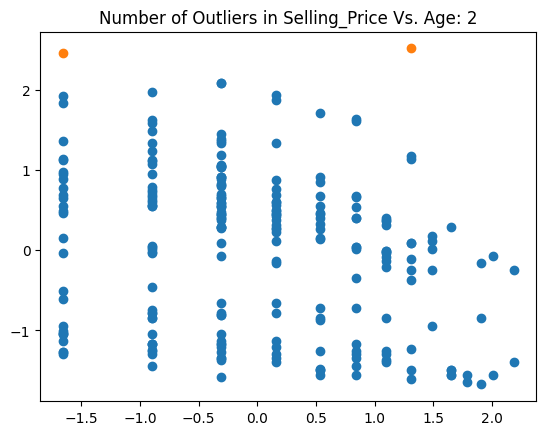

In [ ]:
# Outliers in Age
flags = clean_train_df.Selling_Price > 2.1
count = flags.sum()

plt.scatter(clean_train_df.Age[~flags], clean_train_df.Selling_Price[~flags])
plt.scatter(clean_train_df.Age[flags], clean_train_df.Selling_Price[flags])
plt.title(f'Number of Outliers in Selling_Price Vs. Age: {count}')

In [ ]:
# dropping the flagged outliers

print(f'Number of samples before dropping the outliers:{clean_train_df.shape[0]}')
print(f'Number of outliers to drop:{count}')

# drop
clean_train_df = clean_train_df[~flags]

print(f'Number of samples after dropping the outliers:{clean_train_df.shape[0]}')

Number of samples before dropping the outliers:235
Number of outliers to drop:2
Number of samples after dropping the outliers:233


Text(0.5, 1.0, 'Number of Outliers in Selling_Price Vs. Present_Price: 2')

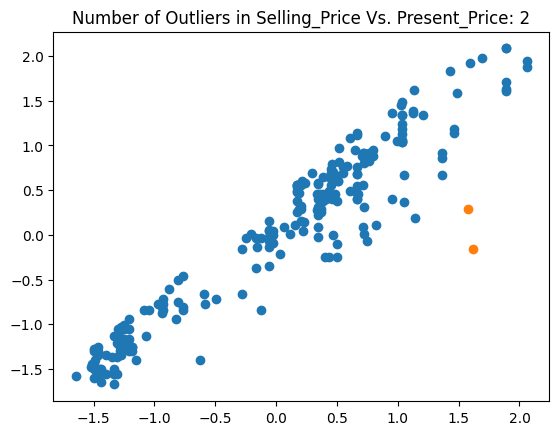

In [ ]:
# Outliers in Present_Price
flags = (clean_train_df.Present_Price > 1.2) & (clean_train_df.Selling_Price < 0.5)
count = flags.sum()

plt.scatter(clean_train_df.Present_Price[~flags], clean_train_df.Selling_Price[~flags])
plt.scatter(clean_train_df.Present_Price[flags], clean_train_df.Selling_Price[flags])
plt.title(f'Number of Outliers in Selling_Price Vs. Present_Price: {count}')

In [ ]:
# dropping the flagged outliers

print(f'Number of samples before dropping the outliers:{clean_train_df.shape[0]}')
print(f'Number of outliers to drop:{count}')

# drop
clean_train_df = clean_train_df[~flags]

print(f'Number of samples after dropping the outliers:{clean_train_df.shape[0]}')

Number of samples before dropping the outliers:233
Number of outliers to drop:2
Number of samples after dropping the outliers:231


Text(0.5, 1.0, 'Number of Outliers in Selling_Price Vs. Kms_Driven: 2')

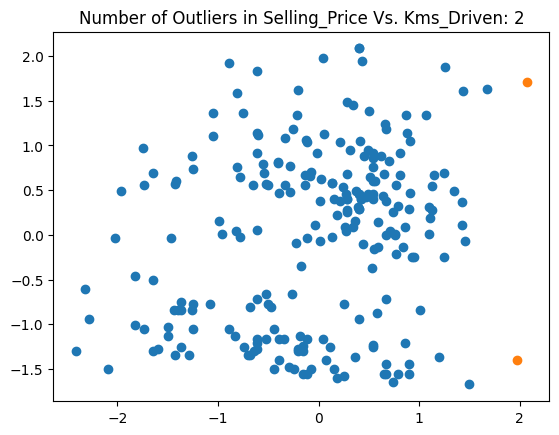

In [ ]:
# Outliers in Kms_Driven
flags= clean_train_df.Kms_Driven > 1.9
count = flags.sum()

plt.scatter(clean_train_df.Kms_Driven[~flags], clean_train_df.Selling_Price[~flags])
plt.scatter(clean_train_df.Kms_Driven[flags], clean_train_df.Selling_Price[flags])
plt.title(f'Number of Outliers in Selling_Price Vs. Kms_Driven: {count}')

In [ ]:
# dropping the flagged outliers

print(f'Number of samples before dropping the outliers:{clean_train_df.shape[0]}')
print(f'Number of outliers to drop:{count}')

# drop
clean_train_df = clean_train_df[~flags]

print(f'Number of samples after dropping the outliers:{clean_train_df.shape[0]}')

Number of samples before dropping the outliers:231
Number of outliers to drop:2
Number of samples after dropping the outliers:229


Now that bivariate outliers have been identified, the next step is to evaluate their impact on predictive performance. Rather than assuming that removing outliers is always beneficial, we adopt an evidence-driven approach:
* Train regression models with all outliers retained
* Train the same models after outlier removal
* Compare performance metrics

This comparison allows us to determine whether removing outliers improves generalization or unintentionally removes informative extreme cases.

# 🔶Split X & Y

At this stage, two versions of the training dataset are maintained:
* Dataset A (preprocessed_train_df): Includes all observations, retaining potential outliers identified during multivariate analysis.
* Dataset B (clean_train_df): Excludes observations flagged as outliers, based on bivariate relationships between predictors and the target.

Maintaining both versions enables a controlled comparison of model performance with and without outlier removal, ensuring that data cleaning decisions are justified rather than assumed.

In [ ]:
# Dataset A ---> Outliers retained
# Separate the dataset into features (X) and the target variable (y)- Outliers retained
x_train = preprocessed_train_df.drop(columns=['Selling_Price'])
y_train = preprocessed_train_df['Selling_Price']

x_train.shape, y_train.shape

((235, 7), (235,))

In [ ]:
# Dataset B ---> Outliers removed
# Separate the dataset into features (X) and the target variable (y)- Outliers removed
x_train_c = clean_train_df.drop(columns=['Selling_Price'])
y_train_c = clean_train_df['Selling_Price']

x_train_c.shape, y_train_c.shape

((229, 7), (229,))

# 🔶Model Selection

* Dataset A: Preprocessed data with outliers retained
* Dataset B: Preprocessed data after removing multivariate outliers

For both datasets, the same modeling pipeline was used to ensure a fair comparison. The pipeline consists of Min–Max normalization followed by an SGDRegressor with ElasticNet regularization. ElasticNet was selected due to its ability to balance feature sparsity (L1) and coefficient stability (L2), which is particularly useful when dealing with correlated predictors.

In [ ]:
# To be used with dataset A
model = make_pipeline(MinMaxScaler(),
                      SGDRegressor(penalty='elasticnet',
                                   max_iter=5000,
                                   learning_rate='constant',
                                   random_state=42,
                                   loss='squared_error',
                                   early_stopping=True))

## ⮞Train & Hyperparameter Tuning Using Cross Validation

Hyperparameter tuning was conducted in two stages:
1.  RandomizedSearchCV was first applied using a broad search space to identify promising regions for the learning rate (eta0), regularization strength (alpha), and ElasticNet mixing parameter (l1_ratio).
2.  GridSearchCV was then used to perform a fine-grained search around the best parameters identified in the randomized search.

Both searches used 5-fold cross-validation and R² as the evaluation metric. The same pipeline structure and search strategy were applied to both datasets to isolate the effect of outlier removal on model performance.

In [ ]:
# Coarse Grid with RandomizedSearchCV

# Initializing
param_dist = {'sgdregressor__eta0':np.logspace(-3,0,50),
              'sgdregressor__alpha':np.logspace(-4,0,50),
              'sgdregressor__l1_ratio':np.linspace(0,1,10)}

In [ ]:
# Train with dataset A
random_search_1 = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=200, cv=5, random_state=42, n_jobs=-1)
random_search_1.fit(x_train, y_train.to_numpy())

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                             ('sgdregressor',
                                              SGDRegressor(early_stopping=True,
                                                           learning_rate='constant',
                                                           max_iter=5000,
                                                           penalty='elasticnet',
                                                           random_state=42))]),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'sgdregressor__alpha': array([1.00000000e-04, 1.20679264e-04, 1.45634848e-04, 1.75751062e-04,
       2.120950...
       0.06866488, 0.07906043, 0.09102982, 0.10481131, 0.12067926,
       0.13894955, 0.15998587, 0.184207  , 0.21209509, 0.24420531,
       0.28117687, 0.32374575, 0.37275937, 0.42919343, 0.49417134,
       0.5689866 , 0.65512856, 0.75431201, 0.86851137, 1.        ]),
                                        'sgdregressor__l1_ratio': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])},
                   random_state=42)

In [ ]:
# Train with dataset B
random_search_2 = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=200, cv=5, random_state=42, n_jobs=-1)
random_search_2.fit(x_train_c, y_train_c.to_numpy())

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                             ('sgdregressor',
                                              SGDRegressor(early_stopping=True,
                                                           learning_rate='constant',
                                                           max_iter=5000,
                                                           penalty='elasticnet',
                                                           random_state=42))]),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'sgdregressor__alpha': array([1.00000000e-04, 1.20679264e-04, 1.45634848e-04, 1.75751062e-04,
       2.120950...
       0.06866488, 0.07906043, 0.09102982, 0.10481131, 0.12067926,
       0.13894955, 0.15998587, 0.184207  , 0.21209509, 0.24420531,
       0.28117687, 0.32374575, 0.37275937, 0.42919343, 0.49417134,
       0.5689866 , 0.65512856, 0.75431201, 0.86851137, 1.        ]),
                                        'sgdregressor__l1_ratio': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])},
                   random_state=42)

In [ ]:
print(f'Randomized Search Best Parameters - Dataset A:{random_search_1.best_params_}')
print(f'Randomized Search Best R2 Score - Dataset A:{random_search_1.best_score_}')

print(f'Randomized Search Best Parameters - Dataset B:{random_search_2.best_params_}')
print(f'Randomized Search Best R2 Score - Dataset B:{random_search_2.best_score_}')

Randomized Search Best Parameters - Dataset A:{'sgdregressor__l1_ratio': np.float64(0.3333333333333333), 'sgdregressor__eta0': np.float64(0.18420699693267165), 'sgdregressor__alpha': np.float64(0.0011513953993264468)}
Randomized Search Best R2 Score - Dataset A:0.9630018404939571
Randomized Search Best Parameters - Dataset B:{'sgdregressor__l1_ratio': np.float64(0.1111111111111111), 'sgdregressor__eta0': np.float64(0.10481131341546852), 'sgdregressor__alpha': np.float64(0.0009540954763499944)}
Randomized Search Best R2 Score - Dataset B:0.9673302556936815


In [ ]:
# Fine Grid with GridSearchCV

# Use the best parameters from random search to define a narrow grid for grid search
random_best_params_1 = random_search_1.best_params_
param_grid_1 = {'sgdregressor__eta0':np.linspace(random_best_params_1['sgdregressor__eta0']*0.9,random_best_params_1['sgdregressor__eta0']*1.1, 10 ),
              'sgdregressor__alpha':np.linspace(random_best_params_1['sgdregressor__alpha']*0.9,random_best_params_1['sgdregressor__alpha']*1.1, 10 ),
              'sgdregressor__l1_ratio':np.linspace(random_best_params_1['sgdregressor__l1_ratio']*0.9,random_best_params_1['sgdregressor__l1_ratio']*1.1, 10 ),
             }

In [ ]:
# Train with dataset A
grid_search_1 = GridSearchCV(model, param_grid=param_grid_1, cv=5, n_jobs=-1)
grid_search_1.fit(x_train, y_train.to_numpy())


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                       ('sgdregressor',
                                        SGDRegressor(early_stopping=True,
                                                     learning_rate='constant',
                                                     max_iter=5000,
                                                     penalty='elasticnet',
                                                     random_state=42))]),
             n_jobs=-1,
             param_grid={'sgdregressor__alpha': array([0.00103626, 0.00106184, 0.00108743, 0.00111302, 0.0011386 ,
       0.00116419, 0.00118978, 0.00121536, 0.00124095, 0.00126653]),
                         'sgdregressor__eta0': array([0.1657863 , 0.16987979, 0.17397327, 0.17806676, 0.18216025,
       0.18625374, 0.19034723, 0.19444072, 0.19853421, 0.2026277 ]),
                         'sgdregressor__l1_ratio': array([0.3       , 0.30740741, 0.31481481, 0.32222222, 0.32962963,
       0.33703704, 0.34444444, 0.35185185, 0.35925926, 0.36666667])})

In [ ]:
# Fine Grid with GridSearchCV

# Use the best parameters from random search to define a narrow grid for grid search
random_best_params_2 = random_search_2.best_params_
param_grid_2 = {'sgdregressor__eta0':np.linspace(random_best_params_2['sgdregressor__eta0']*0.9,random_best_params_2['sgdregressor__eta0']*1.1, 10 ),
              'sgdregressor__alpha':np.linspace(random_best_params_2['sgdregressor__alpha']*0.9,random_best_params_2['sgdregressor__alpha']*1.1, 10 ),
              'sgdregressor__l1_ratio':np.linspace(random_best_params_2['sgdregressor__l1_ratio']*0.9,random_best_params_2['sgdregressor__l1_ratio']*1.1, 10 ),
             }

In [ ]:
# Train with dataset B
grid_search_2 = GridSearchCV(model, param_grid=param_grid_2, cv=5, n_jobs=-1)
grid_search_2.fit(x_train_c, y_train_c.to_numpy())

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                       ('sgdregressor',
                                        SGDRegressor(early_stopping=True,
                                                     learning_rate='constant',
                                                     max_iter=5000,
                                                     penalty='elasticnet',
                                                     random_state=42))]),
             n_jobs=-1,
             param_grid={'sgdregressor__alpha': array([0.00085869, 0.00087989, 0.00090109, 0.00092229, 0.00094349,
       0.0009647 , 0.0009859 , 0.0010071 , 0.0010283 , 0.00104951]),
                         'sgdregressor__eta0': array([0.09433018, 0.09665932, 0.09898846, 0.1013176 , 0.10364674,
       0.10597588, 0.10830502, 0.11063416, 0.1129633 , 0.11529244]),
                         'sgdregressor__l1_ratio': array([0.1       , 0.10246914, 0.10493827, 0.10740741, 0.10987654,
       0.11234568, 0.11481481, 0.11728395, 0.11975309, 0.12222222])})

In [ ]:
print(f'Grid Search Best Parameters - Dataset A:{grid_search_1.best_params_}')
print(f'Grid Search Best R2 Score - Dataset A:{grid_search_1.best_score_}')

print(f'Grid Search Best Parameters - Dataset B:{grid_search_2.best_params_}')
print(f'Grid Search Best R2 Score - Dataset B:{grid_search_2.best_score_}')

Grid Search Best Parameters - Dataset A:{'sgdregressor__alpha': np.float64(0.0010362558593938022), 'sgdregressor__eta0': np.float64(0.18625374134303468), 'sgdregressor__l1_ratio': np.float64(0.3666666666666667)}
Grid Search Best R2 Score - Dataset A:0.9649170842680324
Grid Search Best Parameters - Dataset B:{'sgdregressor__alpha': np.float64(0.000858685928714995), 'sgdregressor__eta0': np.float64(0.10830502386265081), 'sgdregressor__l1_ratio': np.float64(0.12222222222222223)}
Grid Search Best R2 Score - Dataset B:0.9675847893767662


| Dataset   | Outliers |Best Learning Rate|Best Alpha |Best L1  | Best CV R² |
| --------- | -------- | -----------------|-----------|---------|------------|
| Dataset A | Retained |     **0.1862**   |**0.0010** |**0.367**|**0.9649**  |
| Dataset B | Removed  |     **0.1083**   |**0.0008** |**0.122**|**0.9676**  |

Looking closely at the optimal l1_ratio:
* Dataset A: ~0.37 → heavier L1 penalty. With outliers present, the model benefits from stronger sparsity (L1) to suppress unstable coefficients.
* Dataset B: ~0.12 → mostly L2 penalty. Once extreme observations are removed, the data becomes smoother and better behaved, allowing:
  * smaller learning rate,
  * weaker sparsity,
  * more stable coefficient estimation.
  
  This is strong evidence that outliers were distorting the optimization landscape.

The results show that Dataset B outperformed Dataset A, achieving a higher cross-validated R² score (0.9676 vs. 0.9649). In addition, the optimal hyperparameters for Dataset B favored a lower L1 contribution and weaker regularization, indicating improved stability and reduced sensitivity to extreme observations.

These findings suggest that removing multivariate outliers leads to a more robust and generalizable model. Consequently, Dataset B was selected for final model training and evaluation.

## ⮞Best Model

In [ ]:
# Extract the best fitted pipeline
best_pipeline = grid_search_2.best_estimator_

# Extract the best model
best_model = best_pipeline.named_steps['sgdregressor']

# Coefficients
coefficients = best_model.coef_

# Get  feature names
feature_names = x_train_c.columns

# Combine into a table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.sort_values(by="coefficient", key=abs, ascending=False)

,feature,coefficient
1,Present_Price,2.795874
0,Age,-0.747653
4,Seller_Type_Individual,-0.372624
3,Fuel_Type_Diesel,0.259486
2,Kms_Driven,-0.220452
5,Transmission_Manual,-0.127626
6,Owner_Type_OneOrMoreOwners,0.000000


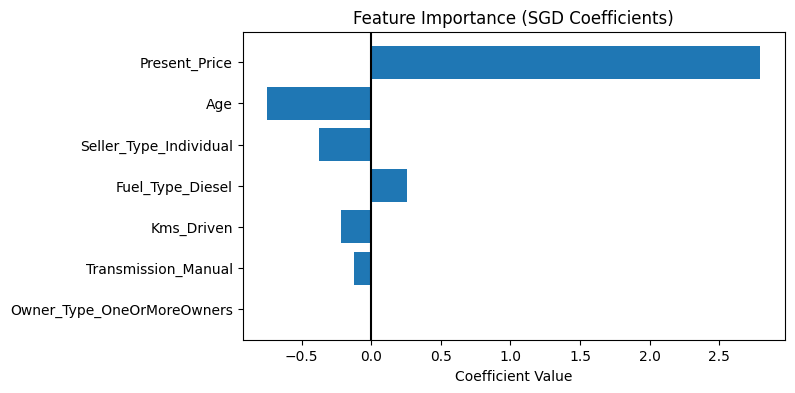

In [ ]:
coef_df_sorted = coef_df.sort_values(by='coefficient', key=abs)

plt.figure(figsize=(7,4))
plt.barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'])
plt.axvline(0, color='k')
plt.title('Feature Importance (SGD Coefficients)')
plt.xlabel('Coefficient Value')
plt.show()


| Feature                               | Interpretation                                                                                                                |
| ------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| **Present_Price (+2.80)**             | Strongest predictor. Higher current market price leads to higher selling price |
| **Age (−0.75)**                       | Older cars consistently sell for less, confirming depreciation effects.                                                       |
| **Seller_Type_Individual (−0.37)**    | Cars sold by individuals tend to have lower prices compared to dealers. |
| **Fuel_Type_Diesel (+0.26)**          | Diesel cars command higher resale prices, likely due to fuel efficiency and durability.                                       |
| **Kms_Driven (−0.22)**                | Higher mileage negatively affects price, but its impact is weaker than age and present price.                                 |
| **Transmission_Manual (−0.13)**       | Manual cars sell for less than automatic ones.                                                       |
| **Owner_Type_OneOrMoreOwners (0.00)** | Effectively eliminated by Elastic Net regularization, indicating negligible predictive contribution.                          |


## ⮞Save the Best Model

In [ ]:
joblib.dump(
    best_pipeline,
    f'best_pipeline_r2_{grid_search_2.best_score_:.4f}.pkl'
)


['best_pipeline_r2_0.9676.pkl']

# 🔶Test the Model

In [ ]:
print(test_df.shape)
test_df.head()

(61, 8)


,Age,Present_Price,Kms_Driven,Owner,Seller_Type,Transmission,Fuel_Type,Selling_Price
177,9.0,0.57,24000.0,0,Individual,Automatic,Petrol,0.35
289,9.0,13.60,10980.0,0,Dealer,Manual,Petrol,10.11
228,13.0,9.40,60000.0,0,Dealer,Manual,Diesel,4.95
198,14.0,0.57,35000.0,1,Individual,Manual,Petrol,0.15
60,12.0,18.61,40001.0,0,Dealer,Manual,Petrol,6.95


## ⮞Teast Set Preprocessing

This section applies the same preprocessing logic used for the training data for the test set, ensuring feature consistency and preventing data leakage.

### ▸Missing Vlues

In [ ]:
test_df.isna().sum()

,0
Age,0
Present_Price,0
Kms_Driven,0
Owner,0
Seller_Type,0
Transmission,0
Fuel_Type,0
Selling_Price,0


### ▸Encoding Categorical Features

In [ ]:
# One-hot-encoding of Owner & Fuel_Type
test_df = pd.get_dummies(test_df, columns=['Owner', 'Fuel_Type'], dtype=np.float64)
test_df.head()

,Age,Present_Price,Kms_Driven,Seller_Type,Transmission,Selling_Price,Owner_0,Owner_1,Owner_3,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
177,9.0,0.57,24000.0,Individual,Automatic,0.35,1.0,0.0,0.0,0.0,0.0,1.0
289,9.0,13.60,10980.0,Dealer,Manual,10.11,1.0,0.0,0.0,0.0,0.0,1.0
228,13.0,9.40,60000.0,Dealer,Manual,4.95,1.0,0.0,0.0,0.0,1.0,0.0
198,14.0,0.57,35000.0,Individual,Manual,0.15,0.0,1.0,0.0,0.0,0.0,1.0
60,12.0,18.61,40001.0,Dealer,Manual,6.95,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Label-encoding binary variables
test_df = pd.get_dummies(test_df, columns=['Seller_Type', 'Transmission'], dtype=np.float64, drop_first=True)
test_df.head()

,Age,Present_Price,Kms_Driven,Selling_Price,Owner_0,Owner_1,Owner_3,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
177,9.0,0.57,24000.0,0.35,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
289,9.0,13.60,10980.0,10.11,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
228,13.0,9.40,60000.0,4.95,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
198,14.0,0.57,35000.0,0.15,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
60,12.0,18.61,40001.0,6.95,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
# Reorder the columns
new_order = [
    'Age',
    'Present_Price',
    'Kms_Driven',
    'Owner_0',
    'Owner_1',
    'Owner_3',
    'Fuel_Type_CNG',
    'Fuel_Type_Diesel',
    'Fuel_Type_Petrol',
    'Seller_Type_Individual',
    'Transmission_Manual',
    'Selling_Price'
]

test_df = test_df.reindex(columns=new_order, fill_value=0)
test_df.head()

,Age,Present_Price,Kms_Driven,Owner_0,Owner_1,Owner_3,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Selling_Price
177,9.0,0.57,24000.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.35
289,9.0,13.60,10980.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,10.11
228,13.0,9.40,60000.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,4.95
198,14.0,0.57,35000.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.15
60,12.0,18.61,40001.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,6.95


### ▸Feature Transformation

The same Yeo–Johnson transformations fitted on the training set are applied to the test data:

In [ ]:
# Apply feature transformation on the test set using the same transformer for each column
feature_cols = ['Age', 'Present_Price', 'Kms_Driven']
target_col = 'Selling_Price'

test_df[feature_cols] = yeoj_x.transform(test_df[feature_cols])
test_df[[target_col]] = yeoj_y.transform(test_df[[target_col]])


### ▸Outlier Detection

#### .Univariate




In [ ]:
# detecting the outliers outside the range of caps
print(upper_cap, lower_cap)
flags = (test_df['Kms_Driven'] < lower_cap) | (test_df['Kms_Driven'] > upper_cap)
print(f'Total Number of samples :{test_df.shape[0]}')
print(f'Number of outliers :{flags.sum()}')
print(f' Shape:{flags.shape}')

2.5288762791747077 -2.5018406869039636
Total Number of samples :61
Number of outliers :0
 Shape:(61,)


In [ ]:
# Total outliers detected through univariate analysis
uni_outliers = flags
uni_outliers_count = uni_outliers.sum()
test_uni_outliers = test_df.loc[uni_outliers]
print(f' Shape:{test_uni_outliers.shape}')
print(f' Total count of univariate outliers:{uni_outliers_count}')

 Shape:(0, 12)
 Total count of univariate outliers:0


#### .Bivariate

In [ ]:
# Outliers in Age
flag1 = test_df.Selling_Price > 2.1
flags_count = flag1.sum()
print(f' Shape:{flag1.shape}')
print(f' Count of outliers:{flags_count}')

# Outliers in Present_Price
flag2 = (test_df.Present_Price > 1.2) & (test_df.Selling_Price < 0.5)
flags_count = flag2.sum()
print(f' Shape:{flag2.shape}')
print(f' Count of outliers:{flags_count}')

# Outliers in Kms_Driven
flag3= test_df.Kms_Driven > 1.9
flags_count = flag3.sum()
print(f' Shape:{flag3.shape}')
print(f' Count of outliers:{flags_count}')

# Total outliers detected through bivariate analysis
bi_outliers = flag1 | flag2 | flag3
bi_outliers_count = bi_outliers.sum()
test_bi_outliers = test_df.loc[bi_outliers]
print(f' Shape:{test_bi_outliers.shape}')
print(f' Total count of bivariate outliers:{bi_outliers_count}')

 Shape:(61,)
 Count of outliers:1
 Shape:(61,)
 Count of outliers:2
 Shape:(61,)
 Count of outliers:1
 Shape:(4, 12)
 Total count of bivariate outliers:4


In [ ]:
# All outliers
all_flags = uni_outliers | bi_outliers
all_flags_count = all_flags.sum()
test_outliers = test_df.loc[all_flags]
print("Shapes --> test_set:", test_df.shape, " test_outliers:", test_outliers.shape)
print("Counts --> uni:", uni_outliers_count, " bi:", bi_outliers_count, " combined:", all_flags_count)

Shapes --> test_set: (61, 12)  test_outliers: (4, 12)
Counts --> uni: 0  bi: 4  combined: 4


Outliers in the test set are identified but not removed, preserving the integrity of the test distribution.

### ▸Data/Feature Reduction

In [ ]:
#Combine the two columns of Owner_1 & Owner_3
test_df.loc[:, 'Owner_Type'] = (
    test_df['Owner_0'].apply(lambda x: 'OneOrMoreOwners' if x == 0 else '0Owners')
)

# Drop old dummy variables
test_df = test_df.drop(columns=['Owner_0', 'Owner_1', 'Owner_3'])

# One-hot encode the new consolidated variable
test_df = pd.get_dummies(test_df, columns=['Owner_Type'], drop_first=True)

# Force dummy column to float64
dummy_cols = [col for col in test_df.columns if col.startswith("Owner_Type_")]
test_df[dummy_cols] = test_df[dummy_cols].astype("float64")

test_df.shape


(61, 10)

In [ ]:
# Removing Fuel_Type_CNG column
test_df = test_df.drop(columns=['Fuel_Type_CNG'])

# Remove 'Fuel_Type_Petrol' feature because Fuel_Type_Diesel is 0 and 1 (0 mean Fuel_Type_Petrol and 1 mean Fuel_Type_Diesel)
test_df = test_df.drop(columns=['Fuel_Type_Petrol'])
test_df.shape

(61, 8)

In [ ]:
# Move target variable (Selling_Price) to the last column
cols = [col for col in test_df.columns if col != 'Selling_Price']
cols.append('Selling_Price')
test_df = test_df[cols]
test_df.head()

,Age,Present_Price,Kms_Driven,Fuel_Type_Diesel,Seller_Type_Individual,Transmission_Manual,Owner_Type_OneOrMoreOwners,Selling_Price
177,-0.897484,-1.449811,-0.158690,0.0,1.0,0.0,0.0,-1.394817
289,-0.897484,1.036718,-0.889926,0.0,0.0,1.0,0.0,1.228497
228,0.836337,0.661154,0.902911,1.0,0.0,1.0,0.0,0.495712
198,1.091890,-1.449811,0.249025,0.0,1.0,1.0,1.0,-1.612585
60,0.529106,1.362571,0.402881,0.0,0.0,1.0,0.0,0.840203


### ▸Split X & Y

In [ ]:
# Separate the marked outliers
test_outliers = test_df.loc[all_flags]

# Split X & Y in normal test set
x_test = test_df.drop(columns=['Selling_Price'])
y_test = test_df['Selling_Price']
print(x_test.shape, y_test.shape)

# Split X & Y in outliers
x_test_o = test_outliers.drop(columns=['Selling_Price'])
y_test_o = test_outliers['Selling_Price']
print(x_test_o.shape, y_test_o.shape)

(61, 7) (61,)
(4, 7) (4,)


## ⮞Load the Model

In [ ]:
model = joblib.load(f'best_pipeline_r2_{grid_search_2.best_score_:.4f}.pkl')


## ⮞Test the Model

In [ ]:
print(f'R2-Score on train data {model.score(x_train_c , y_train_c)}')
print(f'R2-Score on test data {model.score(x_test , y_test)}')

R2-Score on train data 0.9696275483071329
R2-Score on test data 0.9443502061956743


The slight reduction in performance on the test set is expected and indicates that the model generalizes well without evidence of overfitting. The gap between training and test performance remains small, suggesting that the regularization strategy and feature transformations are effective.

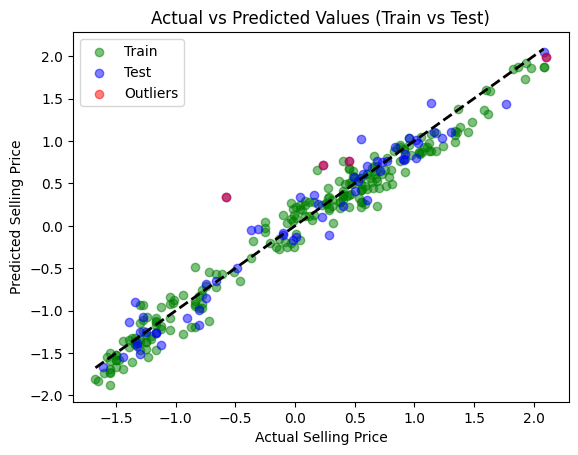

In [ ]:
y_train_pred = model.predict(x_train_c)
y_test_pred = model.predict(x_test)
y_outliers_pred = model.predict(x_test_o)


plt.scatter(y_train_c, y_train_pred, label='Train', alpha=0.5, c='g')
plt.scatter(y_test, y_test_pred, label='Test', alpha=0.5, c='b')
plt.scatter(y_test_o, y_outliers_pred, label='Outliers', alpha=0.5, c='r')


plt.plot([y_train_c.min(), y_train_c.max()],
         [y_train_c.min(), y_train_c.max()],
         'k--', linewidth=2)

plt.title("Actual vs Predicted Values (Train vs Test)")
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.legend()
plt.show()

The scatter plot compares actual versus predicted target values for all three groups:
* Training data (green):
Points lie close to the 45° reference line, indicating a strong fit without excessive variance.
* Test data (blue):
Except for a few samples, points remain tightly clustered around the diagonal, confirming that the learned relationships generalize well to unseen data and suggesting that the feature engineering and transformations were appropriate.
* Flagged outliers (red):
At least one flagged observation deviates noticeably from the diagonal, validating the earlier outlier detection process. This confirms that the outlier behaves differently from the majority of the data and justifies its separation for diagnostic purposes.

The dashed diagonal represents a perfect prediction scenario. The close alignment of most points with this line indicates low bias.

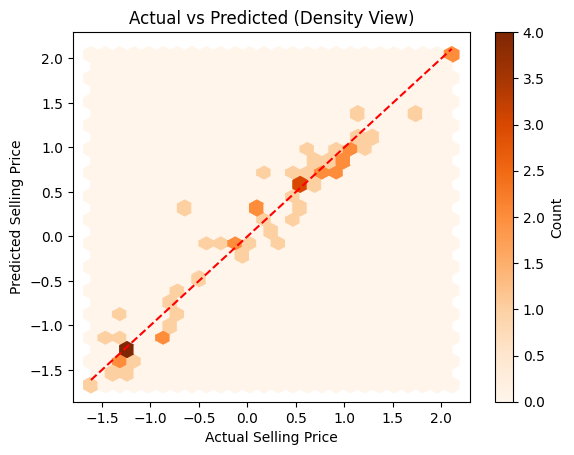

In [ ]:
plt.hexbin(y_test, y_test_pred, gridsize=25, cmap='Oranges')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted (Density View)')
plt.colorbar(label='Count')
plt.show()


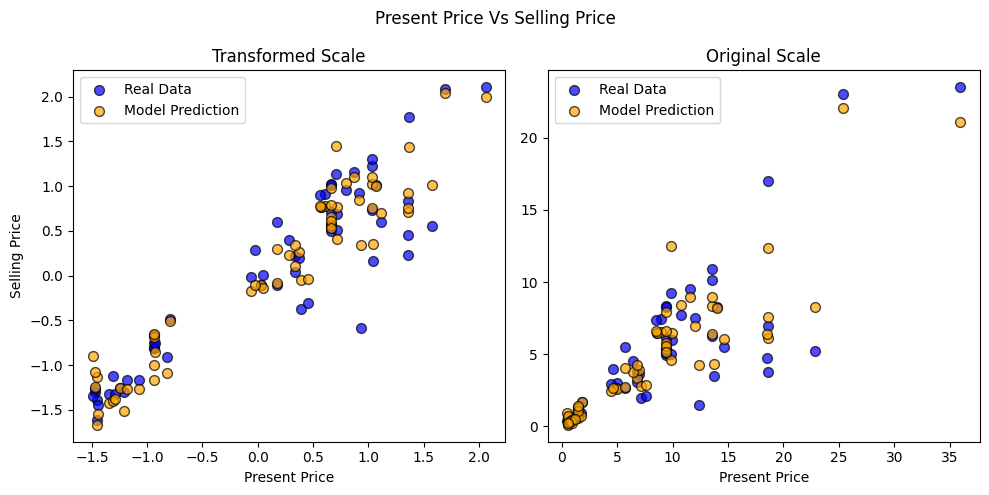

In [ ]:
# Inverse-transform all transformed features
x_test_orig = x_test.copy()
x_test_orig[['Age', 'Present_Price', 'Kms_Driven']] = yeoj_x.inverse_transform(x_test[['Age', 'Present_Price', 'Kms_Driven']])

# Inverse-transform target
y_test_orig = yeoj_y.inverse_transform(pd.DataFrame(y_test, columns=['Selling_Price']))
y_pred_orig = yeoj_y.inverse_transform(pd.DataFrame(y_test_pred, columns=['Selling_Price']))

fig, ax =  plt.subplots(1,2, figsize=(10,5))
plt.suptitle('Present Price Vs Selling Price')

ax[0].scatter(x_test['Present_Price'] , y_test , c='b' , ec='k' , label='Real Data' , s=50 , alpha=0.7);
ax[0].scatter(x_test['Present_Price'] , y_test_pred , c='orange' , ec='k' , label='Model Prediction' , s=50 , alpha=0.7);
ax[0].set_title('Transformed Scale')
ax[0].set_xlabel('Present Price')
ax[0].set_ylabel('Selling Price')
ax[0].legend()

ax[1].scatter(x_test_orig['Present_Price'] , y_test_orig , c='b' , ec='k' , label='Real Data' , s=50 , alpha=0.7);
ax[1].scatter(x_test_orig['Present_Price'] , y_pred_orig , c='orange' , ec='k' , label='Model Prediction' , s=50 , alpha=0.7);
ax[1].set_title('Original Scale')
ax[1].set_xlabel('Present Price')
ax[1].legend()

plt.tight_layout()
plt.show()


The model demonstrates strong predictive performance in the lower price range, where both actual and predicted values closely follow each other. This behavior is expected, as the majority of training samples are concentrated in this region, allowing the model to learn the underlying relationship effectively.

In contrast, predictions in the higher price range exhibit greater dispersion. This can be attributed to the limited number of high-price samples in the dataset, which reduces the model's ability to generalize accurately in this region. As a result, some predicted values deviate noticeably from the actual selling prices.

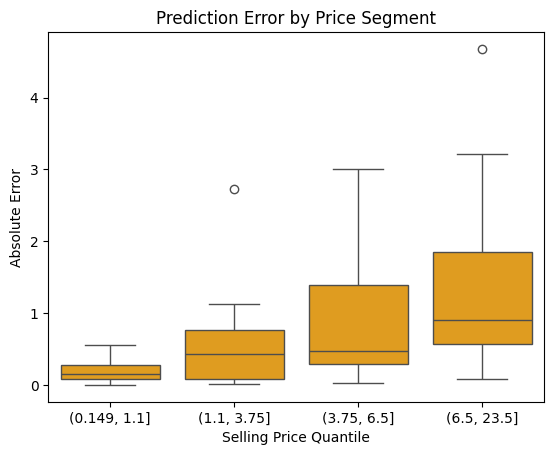

In [ ]:
error_df = pd.DataFrame({
    'price': y_test_orig.flatten(),
    'abs_error': np.abs(y_test_orig.flatten() - y_pred_orig.flatten())
})

error_df['quantile'] = pd.qcut(error_df['price'], q=4)

sns.boxplot(x='quantile', y='abs_error', data=error_df, color='orange')
plt.xlabel('Selling Price Quantile')
plt.ylabel('Absolute Error')
plt.title('Prediction Error by Price Segment')
plt.show()


The absolute prediction error increases as the selling price increases. This indicates that the model performs more accurately in the lower and mid price ranges, while prediction uncertainty grows for higher-priced vehicles. This behavior is consistent with earlier observations and can be attributed to the lower number of training samples in the high-price segment, which limits the model’s ability to generalize in that region.

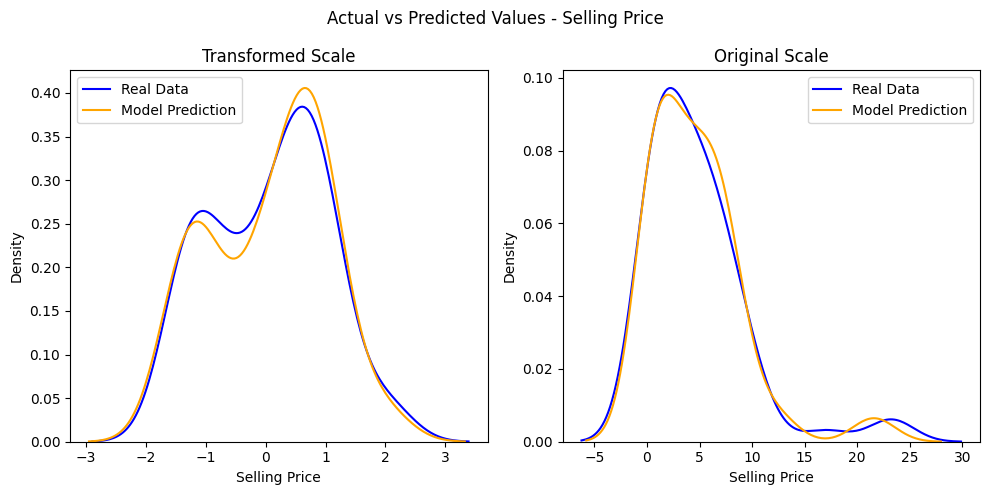

In [ ]:
fig, ax =  plt.subplots(1,2, figsize=(10,5))
plt.suptitle('Actual vs Predicted Values - Selling Price')

sns.kdeplot(y_test , label='Real Data',color='b', ax=ax[0])
sns.kdeplot(y_test_pred , label='Model Prediction',color='orange', ax=ax[0])
ax[0].set_title('Transformed Scale')
ax[0].set_xlabel('Selling Price')
ax[0].legend()

sns.kdeplot(y_test_orig.squeeze() , label='Real Data',color='b', ax=ax[1])
sns.kdeplot(y_pred_orig.squeeze() , label='Model Prediction',color='orange', ax=ax[1])
ax[1].set_title('Original Scale')
ax[1].set_xlabel('Selling Price')
ax[1].legend()

plt.tight_layout()
plt.show()

The KDE plots show strong overlap between actual and predicted selling prices in both transformed and original scales, indicating that the model successfully learns the overall distribution of the target variable. While individual extreme values are not predicted exactly—particularly in the high-price region where data is sparse—the model preserves the tail structure of the distribution. The higher density values in the transformed space are expected due to variance compression introduced by the Yeo–Johnson transformation. Overall, this behavior reflects a well-regularized model that generalizes effectively without overfitting rare extreme cases.

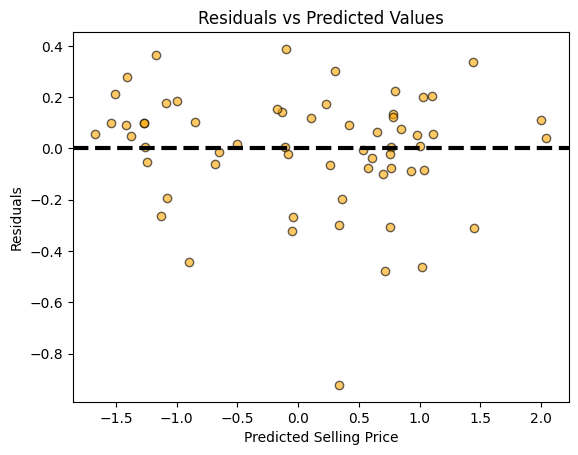

In [ ]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals,c='orange', ec='k', alpha=0.6)
plt.axhline(0, color='k', linestyle='--', lw=3)
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()


The residuals are randomly scattered around the zero line, with most values lying within the range of approximately −0.5 to 0.4. This pattern suggests that the model does not exhibit systematic bias and that the linear assumptions are reasonably satisfied.
A single observation shows a larger negative residual (below −0.8), indicating a potential influential or atypical data point. However, since this deviation is isolated and not part of a broader pattern, it does not undermine the overall model fit.

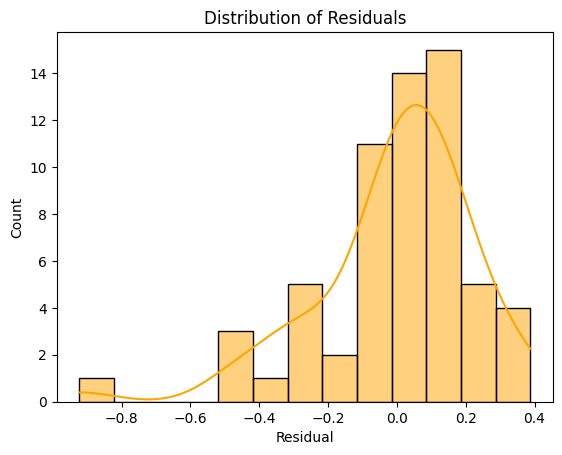

In [ ]:
sns.histplot(residuals, kde=True, color='orange')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.show()


In the residual distribution, the majority of errors are clustered near zero. This indicates that the model’s predictions are generally unbiased and that large errors are relatively rare.

**Summary:**

The regression model demonstrates stable and unbiased performance across most price ranges, with increasing prediction error at higher prices due to limited sample representation rather than systematic modeling errors.

# 🔶Prediction on New Data

A single, previously unseen vehicle record is introduced to evaluate the trained model's behavior on new data:
* Age : 10
* Present_Price : 11.23
* Kms_Driven : 42000
* Fuel_Type : Petrol
* Seller_Type : Dealer
* Transmission : Manual
* Owner : 1

The goal is to estimate the Selling Price.


In [ ]:
# new order of dataset: {Age,	Present_Price,	Kms_Driven,	Fuel_Type_Diesel,	Seller_Type_Individual,	Transmission_Manual,	Owner_Type_OneOrMoreOwners,	Selling_Price}
# Prepare X_new (features only-shape(1,7), same order as model expects)
x_new_vals = [10, 11.23, 42000, 0, 0, 1, 1]
feature_cols = [
    'Age', 'Present_Price', 'Kms_Driven',
    'Fuel_Type_Diesel', 'Seller_Type_Individual',
    'Transmission_Manual', 'Owner_Type_OneOrMoreOwners'
]

x_new_df = pd.DataFrame([x_new_vals], columns=feature_cols)

In [ ]:
# Feature transformation
numeric_feature_cols = ['Age', 'Present_Price', 'Kms_Driven']

x_new_df[numeric_feature_cols] = yeoj_x.transform(x_new_df[numeric_feature_cols])

In [ ]:
# Prediction
y_pred_transformed = model.predict(x_new_df)
y_pred_transformed

array([0.69463354])

In [ ]:
# Inverse normalization and transformation
y_pred_original = yeoj_y.inverse_transform(y_pred_transformed.reshape(-1,1)).ravel()[0]

print("Predicted Selling Price (original scale):", y_pred_original)

Predicted Selling Price (original scale): 6.0281346858232085


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


* **Conclusion:**

In this project, a complete and rigorous machine learning pipeline was developed to predict vehicle selling prices, covering data cleaning, feature engineering, transformation, outlier analysis, model training, and evaluation. The final model demonstrated strong predictive performance, achieving a high R2 score on both training and test sets, with a small and expected generalization gap. Diagnostic plots, residual analysis, and price-segment error evaluation confirmed that the model fits the data well, particularly in the low- to mid-price range, while performance degradation at higher price levels was primarily driven by data scarcity. Overall, the results indicate that the model generalizes effectively and captures the key relationships governing vehicle pricing.

* **Future Work:**

Some extensions could further improve this study. First, incorporating additional high-end vehicle samples would help reduce prediction error in the upper price range. Second, alternative modeling approaches such as XGBoost or Random Forests could be explored to better capture non-linear relationships.